In [1]:
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
import re
import math
from pathlib import Path
from collections import defaultdict
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import Lasso, Ridge, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
'''
from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler
'''

warnings.filterwarnings("ignore")

## 1. Load Dataset

In [2]:
dataset = 'hosp_discharge' # hosp_discharge / hosp_only / hosp_discharge_radio

if dataset == 'hosp_discharge':
    train_df = pd.read_csv("../data/processed/hosp_discharge_train.csv")
    test_df = pd.read_csv("../data/processed/hosp_discharge_test.csv")
elif dataset == 'hosp_only':
    train_df = pd.read_csv("../data/processed/hosp_train.csv")
    test_df = pd.read_csv("../data/processed/hosp_test.csv")
elif dataset == 'hosp_discharge_radio':
    train_df = pd.read_csv("../data/processed/hosp_discharge_radio_train.csv")
    test_df = pd.read_csv("../data/processed/hosp_discharge_radio_test.csv")
    
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print(train_df.columns)
print(test_df.columns)
train_df.head()

Index(['subject_id', 'gender', 'anchor_age', 'label', 'has_labs', 'has_omr',
       'has_charte', 'Anion_Gap_mean', 'Bicarbonate_mean', 'Chloride_mean',
       'Creatinine_mean', 'Potassium_mean', 'Sodium_mean',
       'Urea_Nitrogen_mean', 'Glucose_mean', 'Glucose_std', 'Glucose_max',
       'Glucose_min', 'weight_kg_mean', 'height_cm_mean', 'bmi_mean',
       'bp_sys_mean', 'bp_dia_mean', 'htn_any_mention', 'htn_mention_count'],
      dtype='object')
Index(['subject_id', 'gender', 'anchor_age', 'label', 'has_labs', 'has_omr',
       'has_charte', 'Anion_Gap_mean', 'Bicarbonate_mean', 'Chloride_mean',
       'Creatinine_mean', 'Potassium_mean', 'Sodium_mean',
       'Urea_Nitrogen_mean', 'Glucose_mean', 'Glucose_std', 'Glucose_max',
       'Glucose_min', 'weight_kg_mean', 'height_cm_mean', 'bmi_mean',
       'bp_sys_mean', 'bp_dia_mean', 'htn_any_mention', 'htn_mention_count'],
      dtype='object')


,subject_id,gender,anchor_age,label,has_labs,has_omr,has_charte,Anion_Gap_mean,Bicarbonate_mean,Chloride_mean,...,Glucose_std,Glucose_max,Glucose_min,weight_kg_mean,height_cm_mean,bmi_mean,bp_sys_mean,bp_dia_mean,htn_any_mention,htn_mention_count
0,11490928,F,58,1,1,1,1,15.333333,26.666667,102.666667,...,8.020806,106.0,90.0,97.998632,164.7825,35.9,133.333333,74.666667,True,1.0
1,10260703,F,61,1,1,1,1,18.000000,24.400000,99.600000,...,59.104145,271.0,135.0,95.000386,139.7000,48.7,NaN,NaN,True,6.0
2,10435853,F,47,0,1,1,1,12.937500,21.562500,94.062500,...,18.937217,141.0,86.0,NaN,NaN,NaN,123.857143,54.142857,NaN,NaN
3,10946134,M,36,0,1,0,1,14.111111,25.888889,105.666667,...,24.323057,155.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10509739,F,85,1,1,1,1,14.636364,25.727273,100.772727,...,26.651064,197.0,81.0,64.900000,NaN,NaN,110.000000,60.000000,True,1.0


In [3]:
# train = train.dropna(subset=['Listening_Time_minutes'])
print(train_df.shape)
print(test_df.shape)

(29519, 27)
(7380, 27)


In [9]:
train_counts = train_df.nunique().reset_index()
train_counts.columns = ['Column', 'Train Unique']
test_counts = test_df.nunique().reset_index()
test_counts.columns = ['Column', 'Test Unique']
merged_counts = pd.merge(train_counts, test_counts, on='Column', how='outer')
merged_counts

,Column,Train Unique,Test Unique
0,subject_id,29519,7380
1,gender,2,2
2,anchor_age,73,73
3,label,2,2
4,has_labs,2,2
5,has_omr,2,2
6,has_charte,1,1
7,Anion_Gap_mean,4767,1815
8,Bicarbonate_mean,5326,1963
9,Chloride_mean,5795,2127


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29519 entries, 0 to 29518
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subject_id          29519 non-null  int64  
 1   gender              29519 non-null  object 
 2   anchor_age          29519 non-null  int64  
 3   label               29519 non-null  int64  
 4   has_labs            29519 non-null  int64  
 5   has_omr             29519 non-null  int64  
 6   has_charte          29519 non-null  int64  
 7   Anion_Gap_mean      28136 non-null  float64
 8   Bicarbonate_mean    28139 non-null  float64
 9   Chloride_mean       28173 non-null  float64
 10  Creatinine_mean     28556 non-null  float64
 11  Potassium_mean      28189 non-null  float64
 12  Sodium_mean         28182 non-null  float64
 13  Urea_Nitrogen_mean  28422 non-null  float64
 14  Glucose_mean        28388 non-null  float64
 15  Glucose_std         24839 non-null  float64
 16  Gluc

In [11]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7380 entries, 0 to 7379
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   subject_id          7380 non-null   int64  
 1   gender              7380 non-null   object 
 2   anchor_age          7380 non-null   int64  
 3   label               7380 non-null   int64  
 4   has_labs            7380 non-null   int64  
 5   has_omr             7380 non-null   int64  
 6   has_charte          7380 non-null   int64  
 7   Anion_Gap_mean      7048 non-null   float64
 8   Bicarbonate_mean    7048 non-null   float64
 9   Chloride_mean       7055 non-null   float64
 10  Creatinine_mean     7138 non-null   float64
 11  Potassium_mean      7057 non-null   float64
 12  Sodium_mean         7055 non-null   float64
 13  Urea_Nitrogen_mean  7105 non-null   float64
 14  Glucose_mean        7115 non-null   float64
 15  Glucose_std         6196 non-null   float64
 16  Glucos

In [12]:
missing_values_prop = train_df.isnull().mean()
a = missing_values_prop*100.0
print("missings proportion:\n", a)

missings proportion:
 subject_id             0.000000
gender                 0.000000
anchor_age             0.000000
label                  0.000000
has_labs               0.000000
has_omr                0.000000
has_charte             0.000000
Anion_Gap_mean         4.685118
Bicarbonate_mean       4.674955
Chloride_mean          4.559775
Creatinine_mean        3.262306
Potassium_mean         4.505573
Sodium_mean            4.529286
Urea_Nitrogen_mean     3.716251
Glucose_mean           3.831431
Glucose_std           15.854196
Glucose_max            3.831431
Glucose_min            3.831431
weight_kg_mean        25.505607
height_cm_mean        36.620482
bmi_mean              41.976354
bp_sys_mean           32.070870
bp_dia_mean           32.070870
htn_any_mention       61.082693
htn_mention_count     61.082693
dtype: float64


In [13]:
missing_values_prop = test_df.isnull().mean()
a = missing_values_prop*100.0
print("missings proportion:\n", a)

missings proportion:
 subject_id             0.000000
gender                 0.000000
anchor_age             0.000000
label                  0.000000
has_labs               0.000000
has_omr                0.000000
has_charte             0.000000
Anion_Gap_mean         4.498645
Bicarbonate_mean       4.498645
Chloride_mean          4.403794
Creatinine_mean        3.279133
Potassium_mean         4.376694
Sodium_mean            4.403794
Urea_Nitrogen_mean     3.726287
Glucose_mean           3.590786
Glucose_std           16.043360
Glucose_max            3.590786
Glucose_min            3.590786
weight_kg_mean        25.311653
height_cm_mean        37.357724
bmi_mean              41.707317
bp_sys_mean           31.693767
bp_dia_mean           31.693767
htn_any_mention       60.650407
htn_mention_count     60.650407
dtype: float64


#### inspect missingness from a new sight

In [9]:
print(f"{len(train_df[train_df['has_labs'] == 0])} instances from 29519 do not have labs measurements! (anion, sodium...)")
print(f"{len(train_df[train_df['has_omr'] == 0])} instances from 29519 do not have omr measurements! (weight, bp...)")
print(f"{len(train_df[train_df['has_charte'] == 1])} instances from 29519 have icu measurements! (rr, heart rate...)")
print(f"{len(train_df[(train_df['has_labs'] == 0) & (train_df['has_omr'] == 0)])} instances from 29519 do not have hosp measurements!")

print(f"rows with 5 or more missing values: {(train_df.isna().sum(axis=1) >= 5).sum()}")
print(f"rows with 6 or more missing values: {(train_df.isna().sum(axis=1) >= 6).sum()}")
print(f"rows with 10 or more missing values: {(train_df.isna().sum(axis=1) >= 10).sum()}")
print(f"rows with 12 or more missing values: {(train_df.isna().sum(axis=1) >= 12).sum()}")

796 instances from 29519 do not have labs measurements! (anion, sodium...)
6472 instances from 29519 do not have omr measurements! (weight, bp...)
29519 instances from 29519 have icu measurements! (rr, heart rate...)
578 instances from 29519 do not have hosp measurements!
rows with 5 or more missing values: 7131
rows with 6 or more missing values: 3416
rows with 10 or more missing values: 1097
rows with 12 or more missing values: 908


In [10]:
print(f"{len(test_df[test_df['has_labs'] == 0])} instances from 7380 do not have labs measurements! (anion, sodium...)")
print(f"{len(test_df[test_df['has_omr'] == 0])} instances from 7380 do not have omr measurements! (weight, bp...)")
print(f"{len(test_df[test_df['has_charte'] == 1])} instances from 7380 have icu measurements! (rr, heart rate...)")
print(f"{len(test_df[(test_df['has_labs'] == 0) & (test_df['has_omr'] == 0)])} instances from 7380 do not have hosp measurements!")

print(f"rows with 5 or more missing values: {(test_df.isna().sum(axis=1) >= 5).sum()}")
print(f"rows with 6 or more missing values: {(test_df.isna().sum(axis=1) >= 6).sum()}")
print(f"rows with 10 or more missing values: {(test_df.isna().sum(axis=1) >= 10).sum()}")
print(f"rows with 12 or more missing values: {(test_df.isna().sum(axis=1) >= 12).sum()}")

195 instances from 7380 do not have labs measurements! (anion, sodium...)
1592 instances from 7380 do not have omr measurements! (weight, bp...)
7380 instances from 7380 have icu measurements! (rr, heart rate...)
151 instances from 7380 do not have hosp measurements!
rows with 5 or more missing values: 1753
rows with 6 or more missing values: 844
rows with 10 or more missing values: 254
rows with 12 or more missing values: 213


## EDA


#### numerical

Plotting distributions for 17 numeric features...


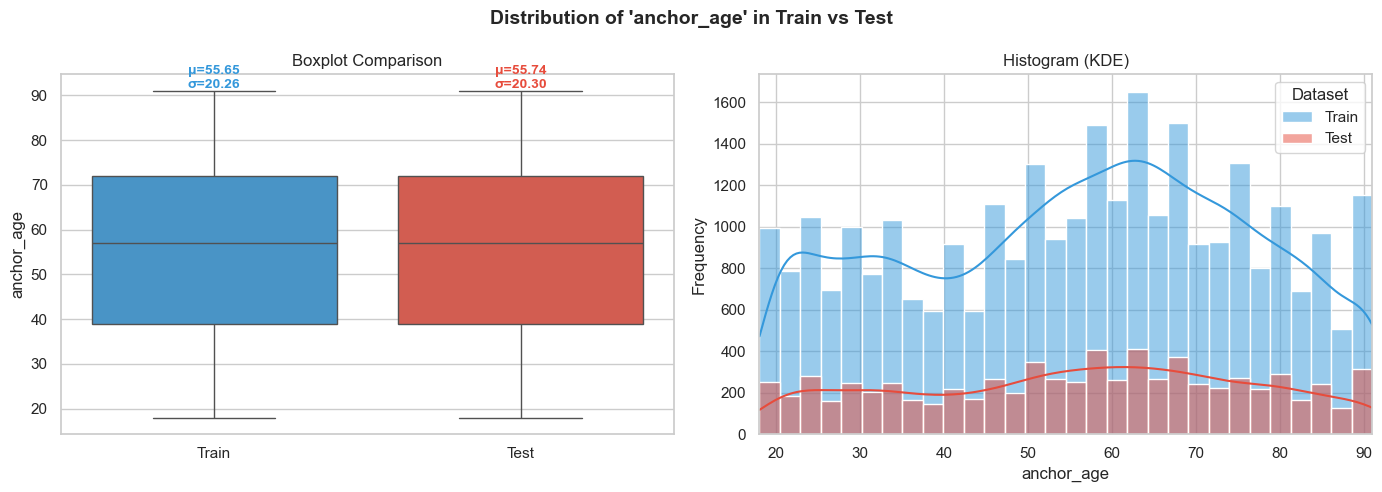

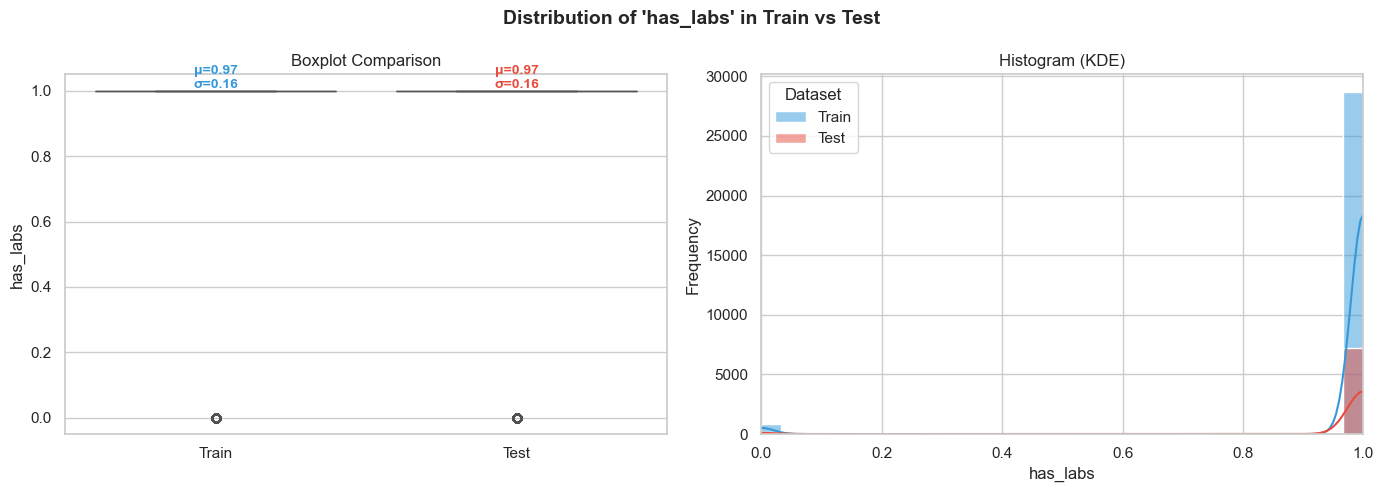

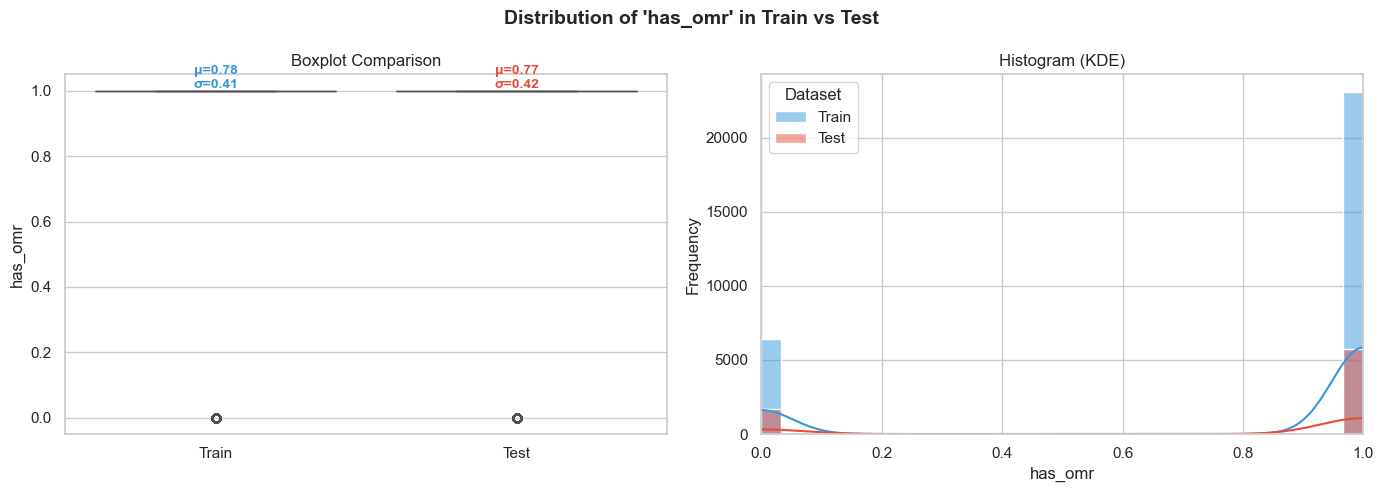

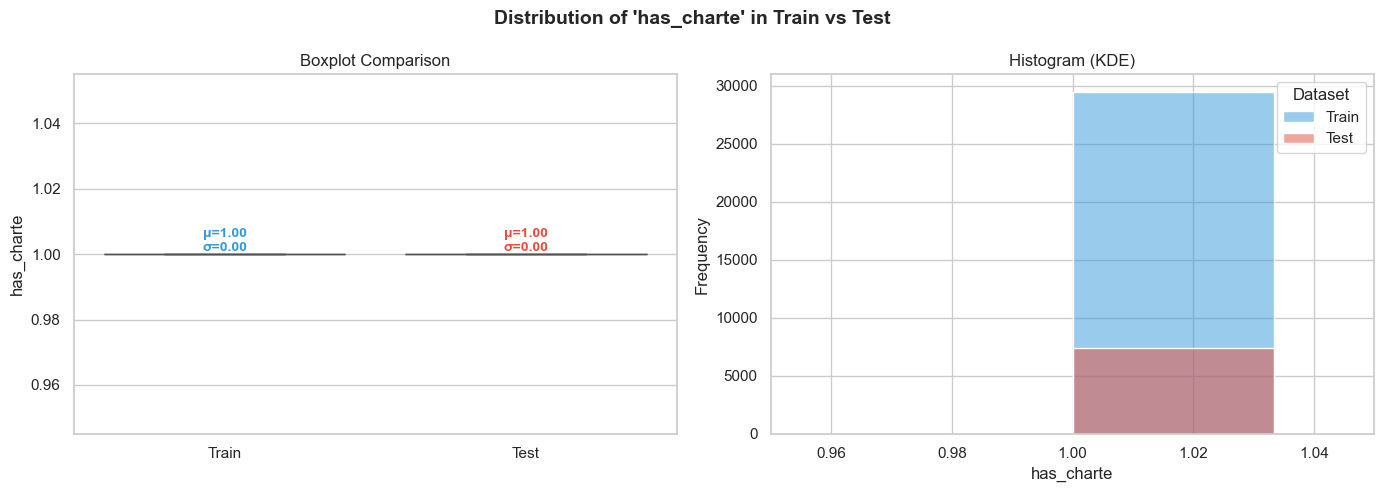

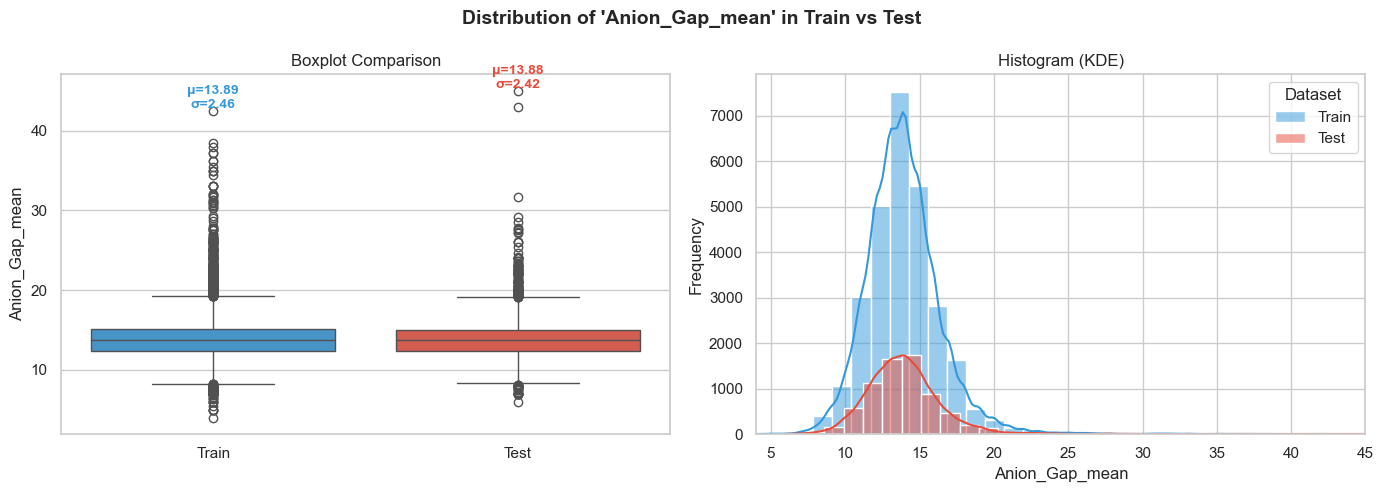

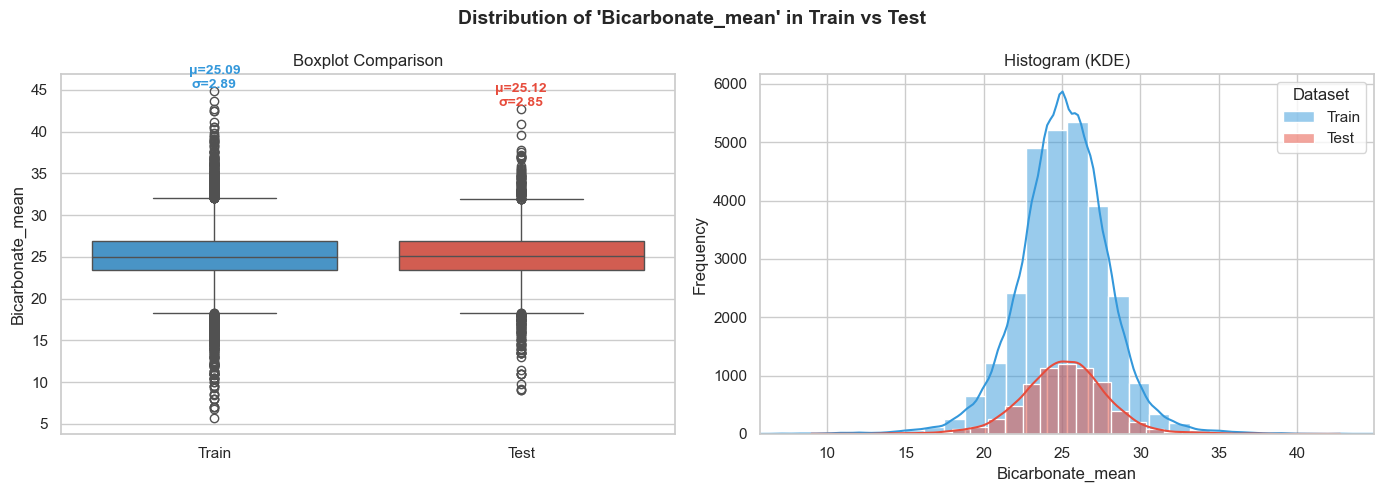

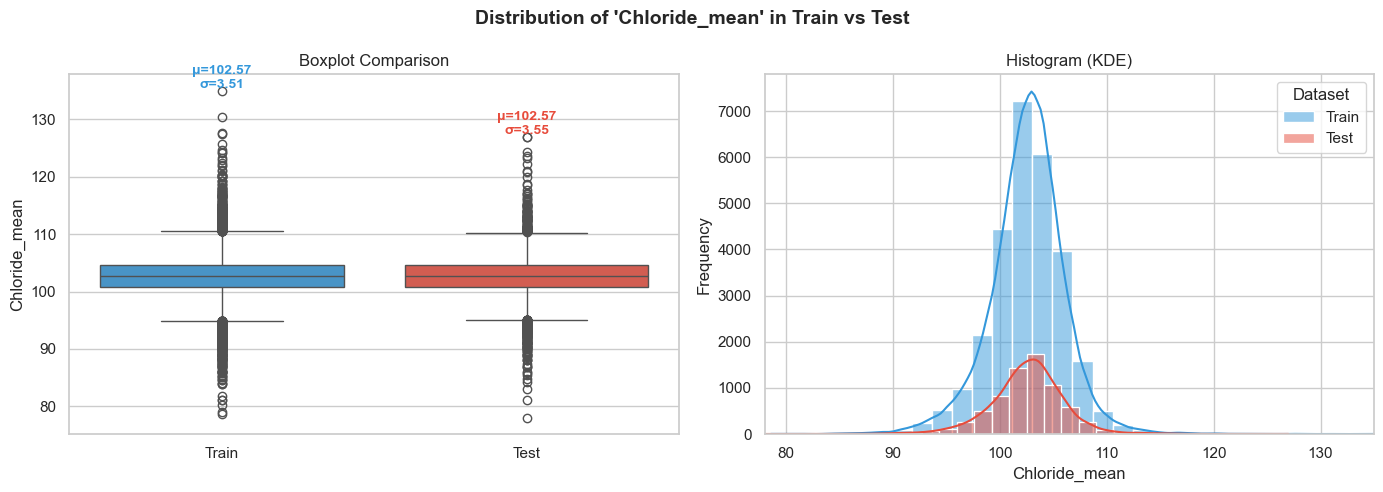

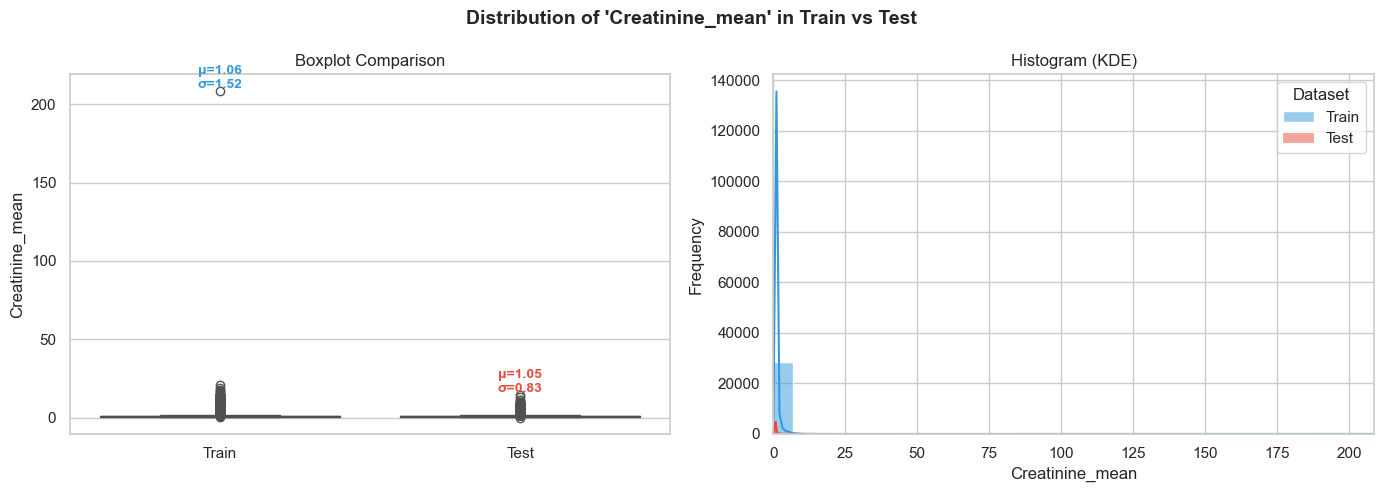

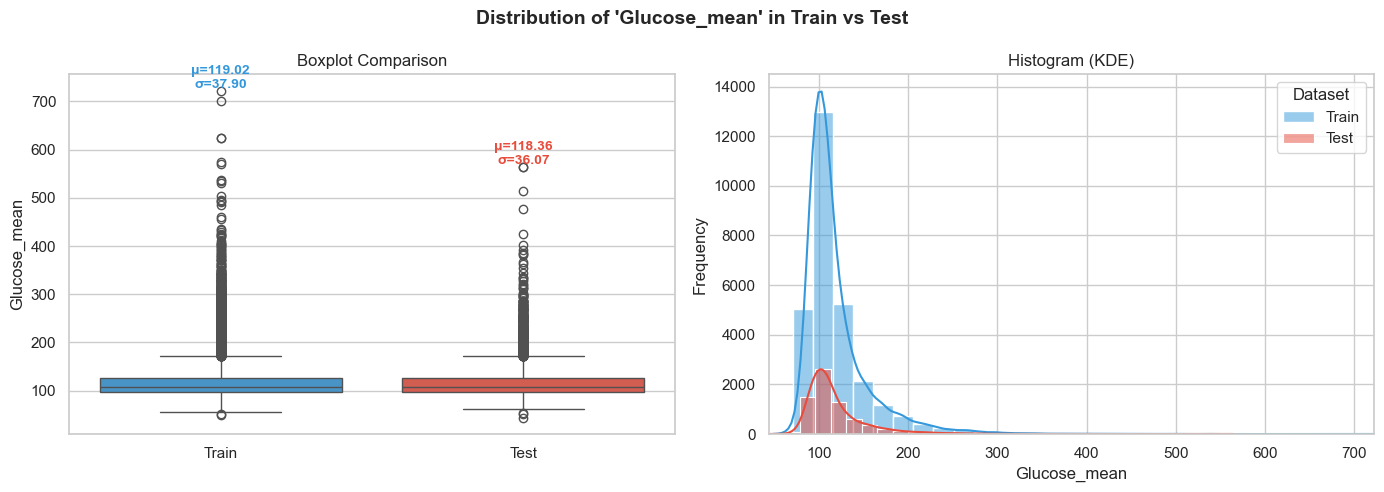

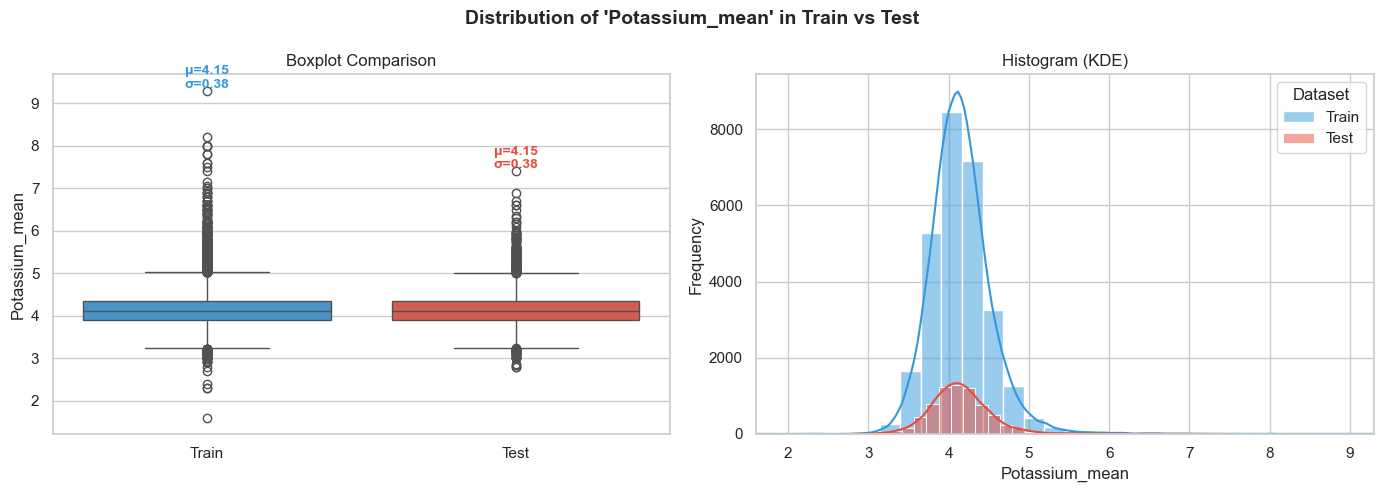

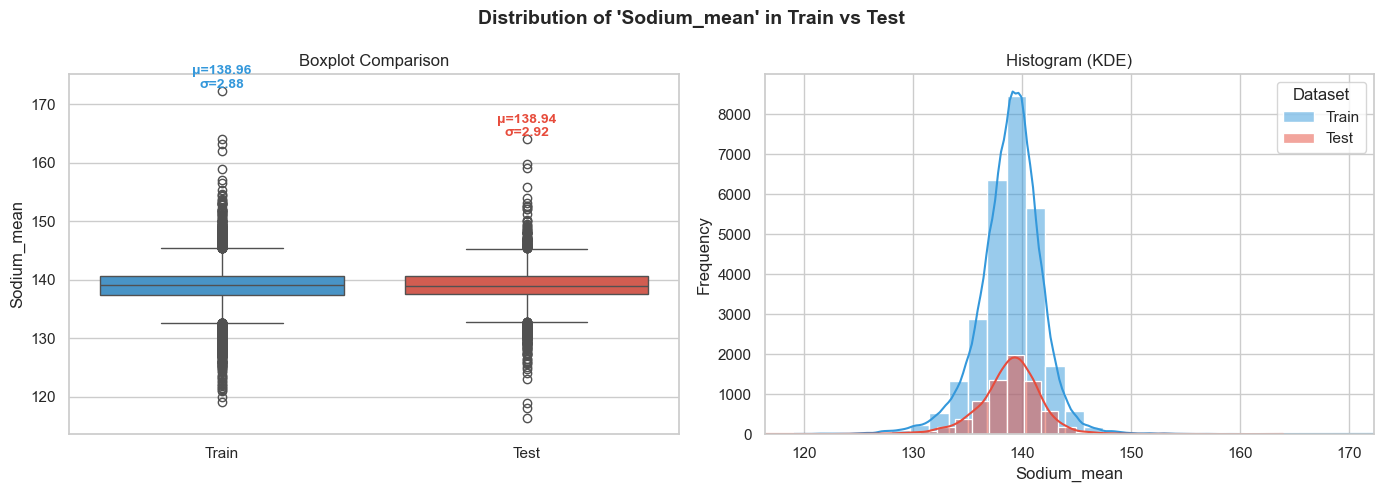

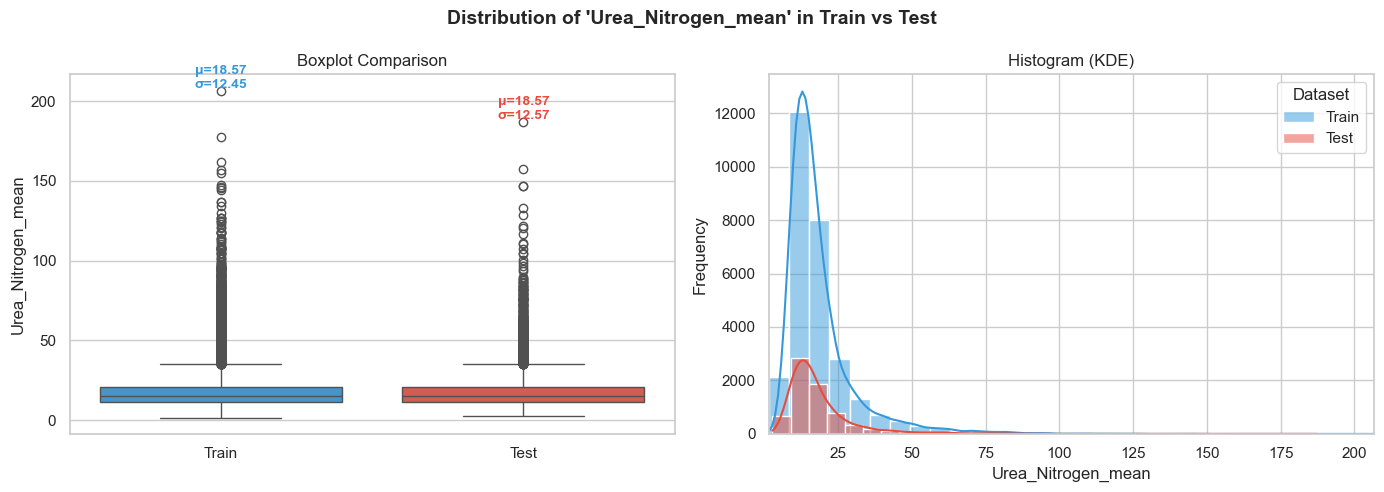

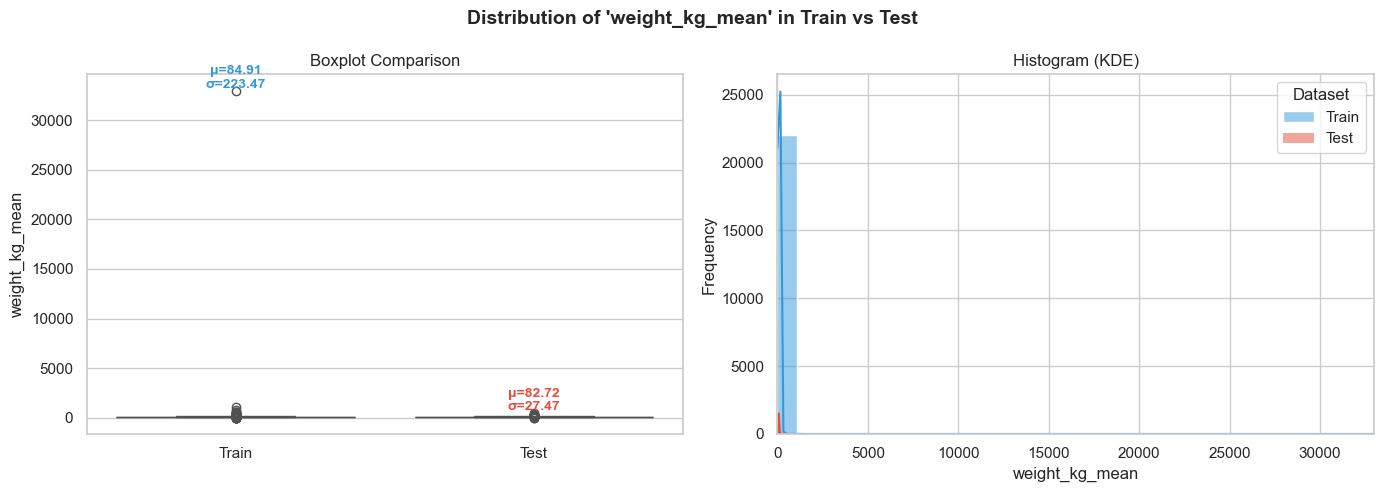

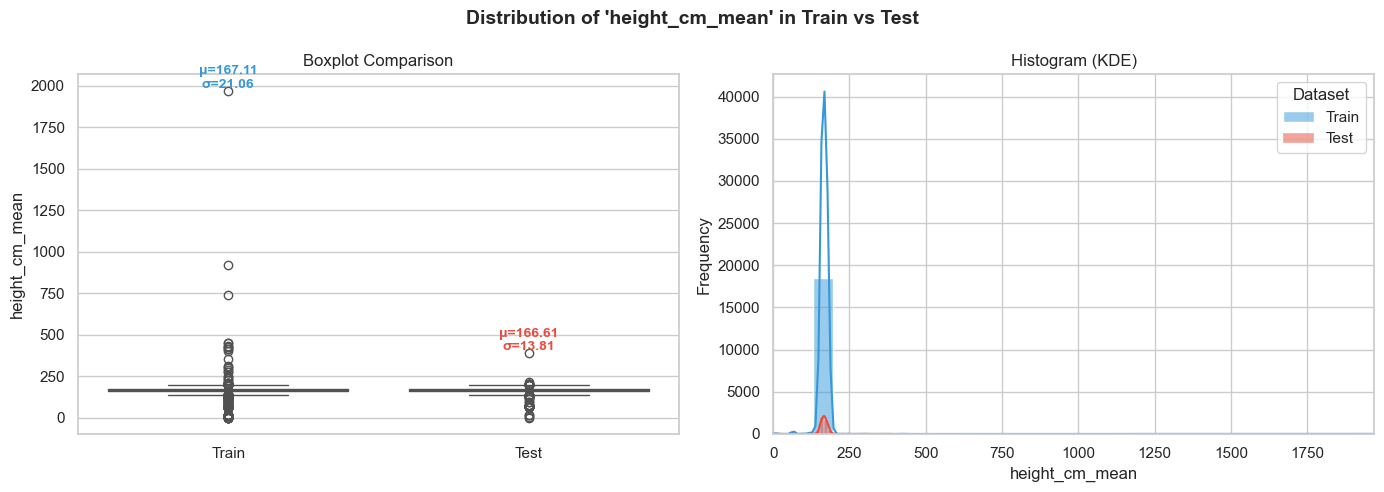

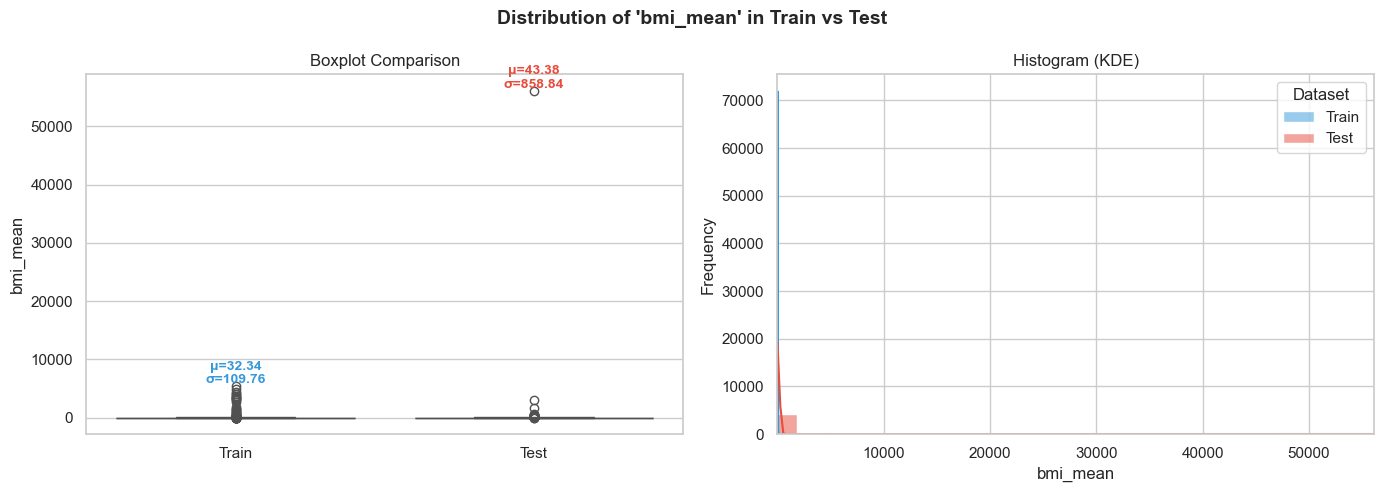

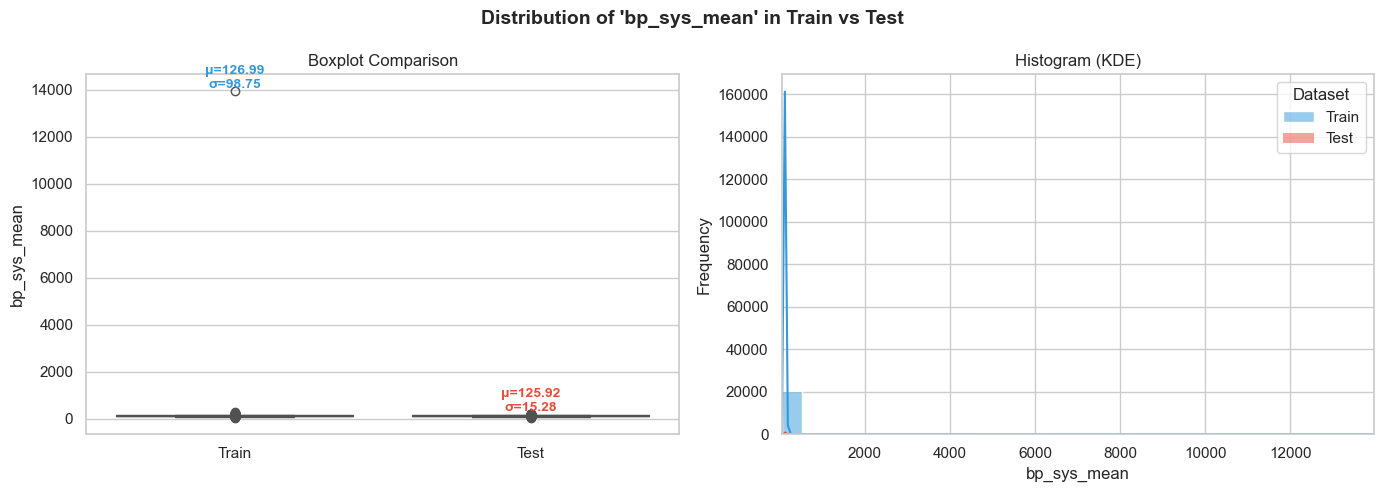

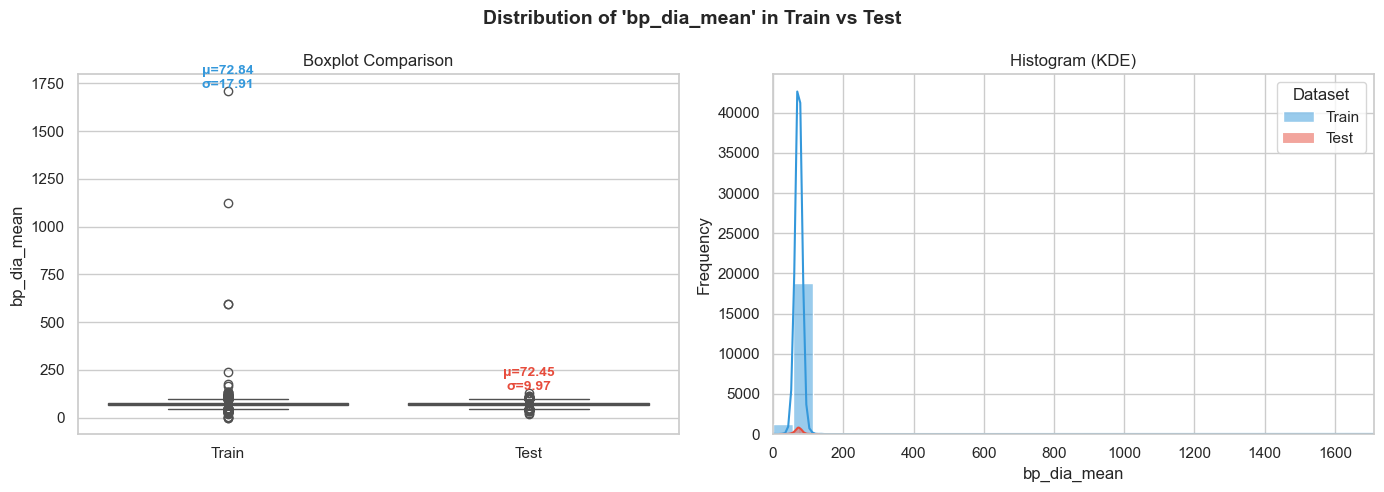

In [13]:
custom_palette = ['#3498db', '#e74c3c', '#2ecc71']

# Tag train/test for comparison
train_df['Source'] = 'Train'
test_df['Source'] = 'Test'

# Combine both for plotting
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# automatically detect numeric columns if not predefined
numerical_variables = combined.select_dtypes(include=np.number).columns.tolist()
# Optionally exclude id or label columns
numerical_variables = [c for c in numerical_variables if c not in ['subject_id', 'label']]

print(f"Plotting distributions for {len(numerical_variables)} numeric features...")

def generate_feature_visualizations(feature_name):
    sns.set(style='whitegrid', font_scale=1.0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Distribution of '{feature_name}' in Train vs Test", fontsize=14, fontweight='bold')

    # Handle missing gracefully
    combined_feature = combined[[feature_name, 'Source']].dropna(subset=[feature_name])

    # ---------------------- BOX PLOT ----------------------
    sns.boxplot(
        data=combined_feature,
        x='Source', y=feature_name,
        palette=custom_palette[:2],
        ax=axes[0]
    )
    axes[0].set_title("Boxplot Comparison", fontsize=12)
    axes[0].set_xlabel("")
    axes[0].set_ylabel(feature_name)

    # Add mean & std annotations
    for source, color in zip(['Train', 'Test'], custom_palette[:2]):
        subset = combined_feature.loc[combined_feature['Source'] == source, feature_name]
        mean_val, std_val = subset.mean(), subset.std()
        axes[0].text(
            x=['Train', 'Test'].index(source),
            y=subset.max() if not np.isnan(subset.max()) else 0,
            s=f"μ={mean_val:.2f}\nσ={std_val:.2f}",
            color=color,
            fontsize=10,
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    # ---------------------- HISTOGRAM ----------------------
    min_val = combined_feature[feature_name].min()
    max_val = combined_feature[feature_name].max()

    sns.histplot(
        data=combined_feature[combined_feature["Source"] == "Train"],
        x=feature_name, color=custom_palette[0],
        kde=True, bins=30, label="Train", alpha=0.5, ax=axes[1]
    )
    sns.histplot(
        data=combined_feature[combined_feature["Source"] == "Test"],
        x=feature_name, color=custom_palette[1],
        kde=True, bins=30, label="Test", alpha=0.5, ax=axes[1]
    )

    axes[1].set_xlim(min_val, max_val)
    axes[1].set_title("Histogram (KDE)", fontsize=12)
    axes[1].set_xlabel(feature_name)
    axes[1].set_ylabel("Frequency")
    axes[1].legend(title="Dataset")

    plt.tight_layout()
    plt.show()

# ---------------------- RUN FOR ALL NUMERIC FEATURES ----------------------
for feature in numerical_variables:
    generate_feature_visualizations(feature)

# Clean up added column
train_df.drop(columns=['Source'], inplace=True)
test_df.drop(columns=['Source'], inplace=True)


In [ ]:
sns.regplot(x="Number_of_Ads", y="Listening_Time_minutes", data=train)

#### Categoricals

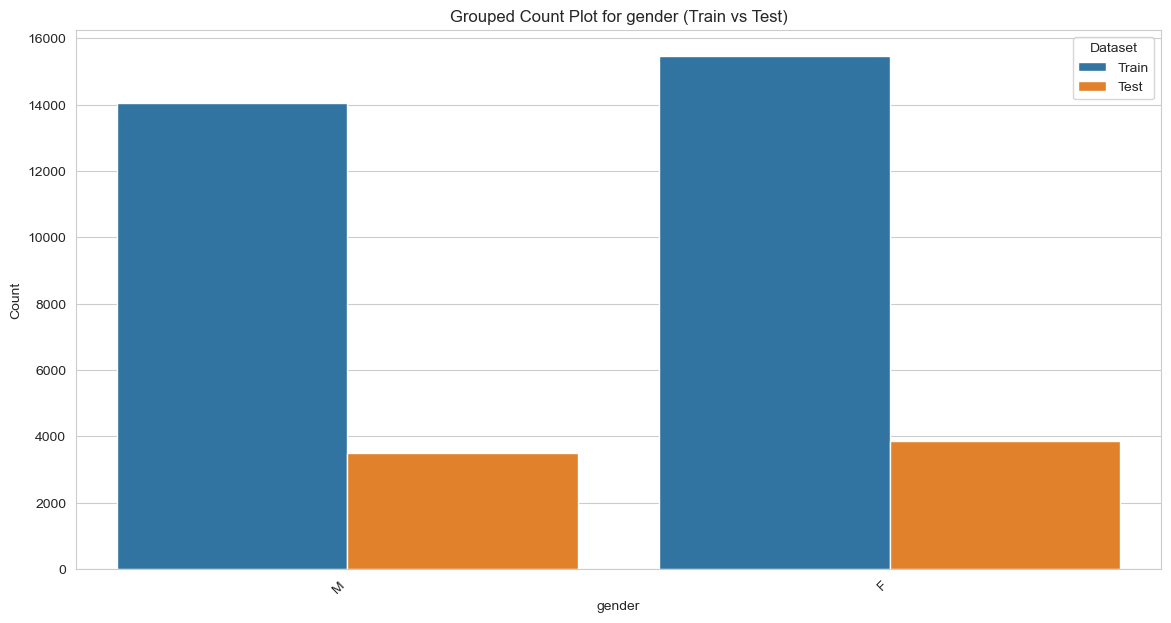

In [11]:
target_variable = 'label' 
categorical_variables = ['gender']

custom_palette = ['#1f77b4', '#ff7f0e']  

def create_grouped_countplot(variable):
    sns.set_style('whitegrid')


    train_data_copy = train_df.copy()
    test_data_copy = test_df.copy()

    train_data_copy['Dataset'] = 'Train'
    test_data_copy['Dataset'] = 'Test'

    combined_data = pd.concat([train_data_copy, test_data_copy])

    train_counts = train_df[variable].value_counts().sort_values(ascending=True).index.tolist()

    plt.figure(figsize=(14, 7))
    sns.countplot(
        data=combined_data, 
        x=variable,  
        hue="Dataset", 
        palette=custom_palette,  
        dodge=True,  
        width=0.85, 
        order=train_counts  
    )

    plt.ylabel("Count")
    plt.xlabel(variable)
    plt.title(f"Grouped Count Plot for {variable} (Train vs Test)")

    plt.xticks(rotation=45, ha="right")

    plt.show()

for variable in categorical_variables:
    create_grouped_countplot(variable)


#### Correlation matrix

In [12]:
variables = [col for col in train_df.columns if col in numerical_variables]

test_variables = variables
train_variables = variables+ ['label']

corr_train = train_df[train_variables].corr()
corr_test = test_df[test_variables].corr()

mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
mask_test = np.triu(np.ones_like(corr_test, dtype=bool))

annot_kws = {"size": 7, "rotation": 45}

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ax_train = sns.heatmap(corr_train, mask=mask_train, cmap='viridis', annot=True,
                      square=True, linewidths=.5, xticklabels=1, yticklabels=1, annot_kws=annot_kws)
plt.title('Correlation Heatmap - Train Data')

plt.subplot(1, 2, 2)
ax_test = sns.heatmap(corr_test, mask=mask_test, cmap='viridis', annot=True,
                     square=True, linewidths=.5, xticklabels=1, yticklabels=1, annot_kws=annot_kws)
plt.title('Correlation Heatmap - Test Data')

plt.tight_layout()

plt.show()

NameError: name 'numerical_variables' is not defined

#### Correlation of features with target

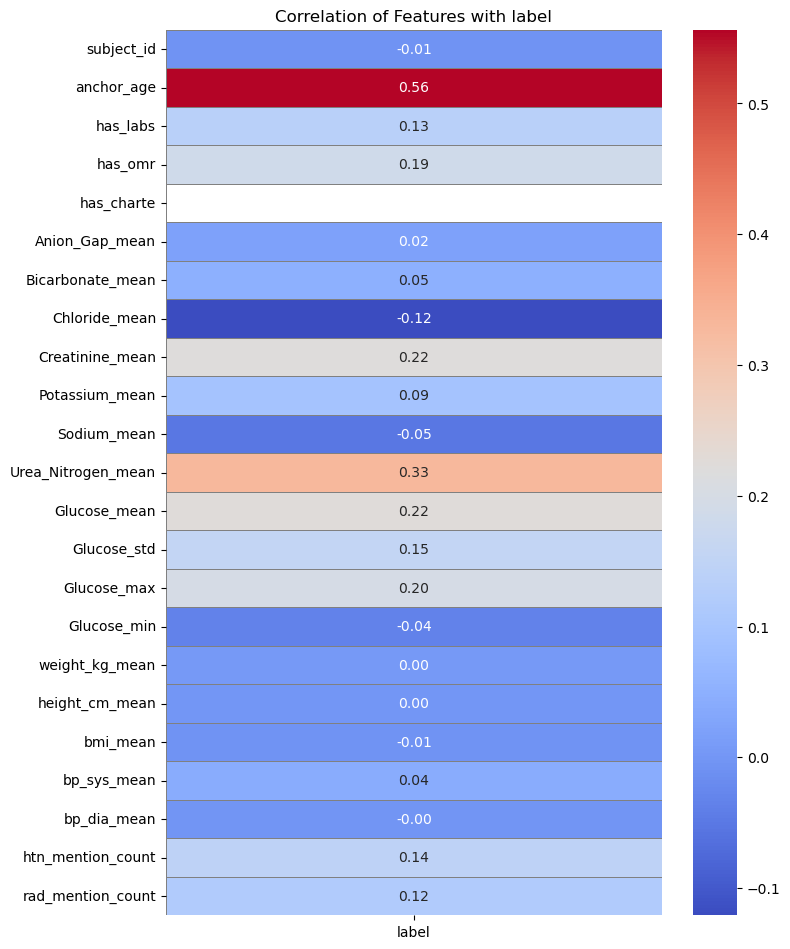

In [4]:
def plot_feature_target_correlation(df, target_column):
    # Select only numerical columns
    numeric_df = df.select_dtypes(include=["number"])

    # Ensure the target column is included in the filtered DataFrame
    if target_column not in numeric_df.columns:
        raise ValueError(f"The target column '{target_column}' is not numeric.")

    # Calculate correlation matrix
    correlation_matrix = numeric_df.corr()

    # Extract correlations of features with the target column
    target_correlation = correlation_matrix[[target_column]].drop(target_column)  # Exclude the target itself

    # Create a heatmap
    plt.figure(figsize=(8, len(target_correlation) * 0.5))
    sns.heatmap(
        target_correlation,
        annot=True,
        cmap="coolwarm",
        cbar=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="gray",
    )
    plt.title(f"Correlation of Features with {target_column}")
    plt.show()

# Example usage
plot_feature_target_correlation(train_df, "label")

## 3. Preprocessing

#### drop columns

In [5]:
train_df.columns

Index(['subject_id', 'gender', 'anchor_age', 'label', 'has_labs', 'has_omr',
       'has_charte', 'Anion_Gap_mean', 'Bicarbonate_mean', 'Chloride_mean',
       'Creatinine_mean', 'Potassium_mean', 'Sodium_mean',
       'Urea_Nitrogen_mean', 'Glucose_mean', 'Glucose_std', 'Glucose_max',
       'Glucose_min', 'weight_kg_mean', 'height_cm_mean', 'bmi_mean',
       'bp_sys_mean', 'bp_dia_mean', 'htn_any_mention', 'htn_mention_count',
       'rad_any_mention', 'rad_mention_count'],
      dtype='object')

In [3]:
train_df = train_df.drop(columns=['has_charte'])
test_df  = test_df.drop(columns=['has_charte'])

train_df = train_df.drop(columns=['bmi_mean'])
test_df  = test_df.drop(columns=['bmi_mean'])

train_df["bmi"] = train_df['weight_kg_mean'] / ((train_df['height_cm_mean'] / 100) ** 2 + 1e-3)
test_df["bmi"] = test_df['weight_kg_mean'] / ((test_df['height_cm_mean'] / 100) ** 2 + 1e-3)

## Train

### AutoGloun

In [5]:
# ===== AutoGluon train -> save outputs -> compute SHAP + Confusion Matrix + Learning Curve =====
import os, json, time, warnings, shutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, auc as sk_auc
)
warnings.filterwarnings("ignore")

# ---------- CONFIG ----------
LABEL = "label"
ID_COL = "subject_id"
AG_SAVE_PATH = f"../models/autogluon_models/{dataset}_180"  # where to save predictor + outputs
TIME_LIMIT = 180           # seconds for AutoGluon fit (adjust)
METRIC = "roc_auc"
NUM_BAG_FOLDS = 5
PRESET = "medium_quality_faster_train" # "medium_quality_faster_train"
MAX_SHAP_ROWS = 200        # if you choose to compute SHAP later
DO_LEARNING_CURVE = True   # set to True to retrain multiple smaller models for bias/variance curve
LC_TIME_LIMIT = 120        # seconds per learning-curve run (reduce if low compute)
LC_FRAC_LIST = [0.05, 0.1, 0.2, 0.4, 1.0]  # training fractions for learning curve
# --------------------------

os.makedirs(AG_SAVE_PATH, exist_ok=True)

# 0) Ensure train_df and test_df exist in memory
if 'train_df' not in globals() or 'test_df' not in globals():
    raise RuntimeError("train_df and test_df must be loaded in memory before running this cell.")

# 1) Prepare train/test (drop ID col)
train_data = train_df.copy()
test_data  = test_df.copy()

if ID_COL in train_data.columns: train_data = train_data.drop(columns=[ID_COL])
if ID_COL in test_data.columns:  test_data  = test_data.drop(columns=[ID_COL])

# Basic checks
assert LABEL in train_data.columns and LABEL in test_data.columns
if train_data[LABEL].isna().any() or test_data[LABEL].isna().any():
    raise ValueError("NaNs found in label column. Fill/remove before training.")

# 2) Train AutoGluon
from autogluon.tabular import TabularPredictor
start = time.time()
print("Starting AutoGluon training... (time_limit={}s)".format(TIME_LIMIT))
predictor = TabularPredictor(label=LABEL, path=AG_SAVE_PATH, eval_metric=METRIC).fit(
    train_data=train_data,
    time_limit=TIME_LIMIT,
    presets=[PRESET],
    verbosity=3,
    num_bag_folds=NUM_BAG_FOLDS
)
t_train = time.time() - start
print(f"AutoGluon training finished in {t_train:.1f}s. Predictor saved to: {AG_SAVE_PATH}")

# 3) Leaderboard, save
lb = predictor.leaderboard(silent=True)
lb_path = os.path.join(AG_SAVE_PATH, "leaderboard.csv")
lb.to_csv(lb_path, index=False)
print("Saved leaderboard:", lb_path)

# 4) Evaluate on test set and save eval_results.json
eval_results = predictor.evaluate(test_data, auxiliary_metrics=True)
eval_path = os.path.join(AG_SAVE_PATH, "eval_results.json")
with open(eval_path, "w") as f:
    json.dump(eval_results, f, indent=4)
print("Saved eval results:", eval_path)

# 5) Predictions and save
X_test = test_data.drop(columns=[LABEL])
y_test = test_data[LABEL].astype(int).values

y_pred = predictor.predict(X_test)
y_proba_df = predictor.predict_proba(X_test)

# choose positive-class probability (binary)
if y_proba_df.shape[1] == 2:
    pos_class = y_proba_df.columns[1]   # usually the positive class
    proba_series = y_proba_df[pos_class]
else:
    proba_series = y_proba_df.iloc[:, -1]

preds_df = test_data.reset_index(drop=True).copy()
preds_df["pred_label"] = y_pred.values
preds_df["pred_proba_pos"] = proba_series.values
pred_path = os.path.join(AG_SAVE_PATH, "test_predictions.csv")
preds_df.to_csv(pred_path, index=False)
print("Saved test predictions:", pred_path)

# 6) Feature importance (permutation importance by AutoGluon)
try:
    best_model_name = predictor.get_model_best()
    fi_df = predictor.feature_importance(test_data, model=best_model_name)
    fi_path = os.path.join(AG_SAVE_PATH, "feature_importance.csv")
    fi_df.to_csv(fi_path)
    print("Saved feature importance (permutation) to:", fi_path)
except Exception as e:
    print("Could not compute AutoGluon permutation feature importance:", e)

# ---------- Confusion matrix & classification report for best model ----------
try:
    best_model = predictor.get_model_best()
    print("Best model:", best_model)
    y_pred_best = predictor.predict(X_test, model=best_model)
    # convert to numeric if necessary
    try:
        y_pred_num = y_pred_best.astype(int)
    except Exception:
        labels = predictor.class_labels
        mapping = {labels[i]: i for i in range(len(labels))}
        y_pred_num = y_pred_best.map(mapping).astype(int)

    cm = confusion_matrix(y_test, y_pred_num)
    cr = classification_report(y_test, y_pred_num, digits=4)
    # save
    np.savetxt(os.path.join(AG_SAVE_PATH, "autogluon_confusion_matrix.csv"), cm, fmt='%d', delimiter=',')
    with open(os.path.join(AG_SAVE_PATH, "autogluon_classification_report.txt"), "w") as f:
        f.write(cr)
    # plot
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion matrix - Best model ({best_model})")
    plt.colorbar()
    tick_marks = np.arange(cm.shape[0])
    plt.xticks(tick_marks, [str(i) for i in range(cm.shape[0])])
    plt.yticks(tick_marks, [str(i) for i in range(cm.shape[0])])
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(os.path.join(AG_SAVE_PATH, "autogluon_confusion_matrix_best_model.png"), dpi=150)
    plt.close()
    print("Saved confusion matrix and classification report to:", AG_SAVE_PATH)
    print("Classification report:\n", cr)
except Exception as e:
    print("Could not compute confusion matrix/class report:", e)

# ---------- ROC curve (best model) ----------
try:
    proba_df = predictor.predict_proba(X_test, model=best_model)
    if pos_class in proba_df.columns:
        y_proba_best = proba_df[pos_class].values
    else:
        y_proba_best = proba_df.iloc[:, -1].values

    # compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba_best)
    roc_auc = roc_auc_score(y_test, y_proba_best)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'Best model ROC (AUC={roc_auc:.4f})')
    plt.plot([0,1],[0,1],'k--', alpha=0.4)
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.title("ROC curve - Best AutoGluon model")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(AG_SAVE_PATH, "autogluon_best_model_roc.png"), dpi=150)
    plt.close()
    print("Saved ROC curve for best model.")
except Exception as e:
    print("Could not compute ROC for best model:", e)

# ---------- Precision-Recall curve ----------
try:
    precision, recall, _ = precision_recall_curve(y_test, y_proba_best)
    pr_auc = sk_auc(recall, precision)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f'PR curve (AUC={pr_auc:.4f})')
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision-Recall curve - Best AutoGluon model")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(os.path.join(AG_SAVE_PATH, "autogluon_best_model_pr_curve.png"), dpi=150)
    plt.close()
    print("Saved precision-recall curve for best model.")
except Exception as e:
    print("Could not compute Precision-Recall curve:", e)

# ---------- Learning curve (bias vs variance) via retraining on fractions ----------
if DO_LEARNING_CURVE:
    print("\nStarting learning-curve retraining (this will retrain multiple AutoGluon runs).")
    LC_DIR = os.path.join(AG_SAVE_PATH, "learning_curve_runs")
    if os.path.exists(LC_DIR):
        shutil.rmtree(LC_DIR)
    os.makedirs(LC_DIR, exist_ok=True)

    lc_results = []
    # use a fixed random seed selection
    for frac in LC_FRAC_LIST:
        n_train = int(len(train_data) * frac)
        if n_train < 50:
            print(f"Skipping frac {frac} (train size {n_train}) — too small.")
            continue
        train_sub = train_data.sample(n_train, random_state=42).reset_index(drop=True)
        run_dir = os.path.join(LC_DIR, f"run_{int(frac*100)}")
        print(f"\nLC run: frac={frac}, n_train={n_train}, run_dir={run_dir}")

        # train Autogluon for this subset (small time limit)
        t0 = time.time()
        predictor_lc = TabularPredictor(label=LABEL, path=run_dir, eval_metric=METRIC).fit(
            train_data=train_sub,
            time_limit=LC_TIME_LIMIT,
            presets=[PRESET],
            verbosity=2
        )
        train_time = time.time() - t0

        # evaluate on train_sub and global test
        try:
            proba_train_df = predictor_lc.predict_proba(train_sub.drop(columns=[LABEL]))
            if pos_class in proba_train_df.columns:
                p_train = proba_train_df[pos_class].values
            else:
                p_train = proba_train_df.iloc[:, -1].values
            train_auc = roc_auc_score(train_sub[LABEL].astype(int).values, p_train)
        except Exception as e:
            print("Could not compute train AUC for this LC run:", e)
            train_auc = np.nan

        try:
            proba_test_df = predictor_lc.predict_proba(X_test)
            if pos_class in proba_test_df.columns:
                p_test = proba_test_df[pos_class].values
            else:
                p_test = proba_test_df.iloc[:, -1].values
            test_auc = roc_auc_score(y_test, p_test)
        except Exception as e:
            print("Could not compute test AUC for this LC run:", e)
            test_auc = np.nan

        lc_results.append({
            "frac": frac,
            "n_train": n_train,
            "train_auc": float(train_auc) if not np.isnan(train_auc) else None,
            "test_auc": float(test_auc) if not np.isnan(test_auc) else None,
            "train_time_s": train_time,
            "run_dir": run_dir
        })

        # free some space by deleting model files if you want (comment out to keep)
        # shutil.rmtree(run_dir)

    lc_df = pd.DataFrame(lc_results).sort_values("n_train")
    lc_df.to_csv(os.path.join(LC_DIR, "learning_curve_results.csv"), index=False)
    # plot learning curve
    plt.figure(figsize=(8,5))
    plt.plot(lc_df.n_train, lc_df.train_auc, marker='o', label='Train AUC')
    plt.plot(lc_df.n_train, lc_df.test_auc, marker='o', label='Test AUC')
    plt.xlabel("Training samples")
    plt.ylabel("AUC")
    plt.title("Learning curve (Train vs Test AUC)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(LC_DIR, "learning_curve_plot.png"), dpi=150)
    plt.close()
    print("Saved learning-curve results + plot to:", LC_DIR)


print("\nAll done. Main outputs stored under:", AG_SAVE_PATH)


Preset alias specified: 'medium_quality_faster_train' maps to 'medium_quality'.
Presets specified: ['medium_quality_faster_train']
============ fit kwarg info ============
User Specified kwargs:
{'auto_stack': False, 'num_bag_folds': 5, 'verbosity': 3}
Full kwargs:
{'_feature_generator_kwargs': None,
 '_save_bag_folds': None,
 'ag_args': None,
 'ag_args_ensemble': None,
 'ag_args_fit': None,
 'auto_stack': False,
 'calibrate': 'auto',
 'excluded_model_types': None,
 'feature_generator': 'auto',
 'feature_prune_kwargs': None,
 'holdout_frac': None,
 'hyperparameter_tune_kwargs': None,
 'included_model_types': None,
 'keep_only_best': False,
 'name_suffix': None,
 'num_bag_folds': 5,
 'num_bag_sets': None,
 'num_stack_levels': None,
 'pseudo_data': None,
 'refit_full': False,
 'save_space': False,
 'set_best_to_refit_full': False,
 'unlabeled_data': None,
 'use_bag_holdout': False,
 'verbosity': 3}
Saving ../models/autogluon_models/hosp_discharge_180\learner.pkl
Saving ../models/autogluo

Starting AutoGluon training... (time_limit=180s)


			Original Features (exact raw dtype, raw dtype):
				('float64', 'float') : 17 | ['Anion_Gap_mean', 'Bicarbonate_mean', 'Chloride_mean', 'Creatinine_mean', 'Potassium_mean', ...]
				('int64', 'int')     :  3 | ['anchor_age', 'has_labs', 'has_omr']
				('object', 'object') :  2 | ['gender', 'htn_any_mention']
			Types of features in original data (raw dtype, special dtypes):
				('float', [])  : 17 | ['Anion_Gap_mean', 'Bicarbonate_mean', 'Chloride_mean', 'Creatinine_mean', 'Potassium_mean', ...]
				('int', [])    :  3 | ['anchor_age', 'has_labs', 'has_omr']
				('object', []) :  2 | ['gender', 'htn_any_mention']
			Types of features in processed data (raw dtype, special dtypes):
				('float', [])     : 17 | ['Anion_Gap_mean', 'Bicarbonate_mean', 'Chloride_mean', 'Creatinine_mean', 'Potassium_mean', ...]
				('int', [])       :  1 | ['anchor_age']
				('int', ['bool']) :  4 | ['gender', 'has_labs', 'has_omr', 'htn_any_mention']
			0.0s = Fit runtime
			22 features in original data u

[50]	valid_set's binary_logloss: 0.372534
[100]	valid_set's binary_logloss: 0.351669
[150]	valid_set's binary_logloss: 0.346974
[200]	valid_set's binary_logloss: 0.345087
[250]	valid_set's binary_logloss: 0.344661
[300]	valid_set's binary_logloss: 0.344505
[350]	valid_set's binary_logloss: 0.34496
[400]	valid_set's binary_logloss: 0.345343


	Fitting 10000 rounds... Hyperparameters: {'learning_rate': 0.05, 'extra_trees': True}


...


LC run: frac=0.4, n_train=11807, run_dir=../models/autogluon_models/hosp_discharge_180\learning_curve_runs\run_40


Automatically generating train/validation split with holdout_frac=0.1, Train Rows: 10626, Val Rows: 1181
User-specified model hyperparameters to be fit:
{
	'NN_TORCH': {},
	'GBM': [{'extra_trees': True, 'ag_args': {'name_suffix': 'XT'}}, {}, 'GBMLarge'],
	'CAT': {},
	'XGB': {},
	'FASTAI': {},
	'RF': [{'criterion': 'gini', 'ag_args': {'name_suffix': 'Gini', 'problem_types': ['binary', 'multiclass']}}, {'criterion': 'entropy', 'ag_args': {'name_suffix': 'Entr', 'problem_types': ['binary', 'multiclass']}}, {'criterion': 'squared_error', 'ag_args': {'name_suffix': 'MSE', 'problem_types': ['regression', 'quantile']}}],
	'XT': [{'criterion': 'gini', 'ag_args': {'name_suffix': 'Gini', 'problem_types': ['binary', 'multiclass']}}, {'criterion': 'entropy', 'ag_args': {'name_suffix': 'Entr', 'problem_types': ['binary', 'multiclass']}}, {'criterion': 'squared_error', 'ag_args': {'name_suffix': 'MSE', 'problem_types': ['regression', 'quantile']}}],
	'KNN': [{'weights': 'uniform', 'ag_args': {'name_


LC run: frac=1.0, n_train=29519, run_dir=../models/autogluon_models/hosp_discharge_180\learning_curve_runs\run_100


		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('float', [])  : 17 | ['Anion_Gap_mean', 'Bicarbonate_mean', 'Chloride_mean', 'Creatinine_mean', 'Potassium_mean', ...]
		('int', [])    :  3 | ['anchor_age', 'has_labs', 'has_omr']
		('object', []) :  2 | ['gender', 'htn_any_mention']
	Types of features in processed data (raw dtype, special dtypes):
		('float', [])     : 17 | ['Anion_Gap_mean', 'Bicarbonate_mean', 'Chloride_mean', 'Creatinine_mean', 'Potassium_mean', ...]
		('int', [])       :  1 | ['anchor_age']
		('int', ['bool']) :  4 | ['gender', 'has_labs', 'has_omr', 'htn_any_mention']
	0.2s = Fit runtime
	22 features in original data used to generate 22 features in processed data.
	Train Data (Processed) Memory Usage: 4.37 MB (0.1% of available memory)
Data preprocessing and feature engineering runtime = 0.21s ...
AutoGluon will gauge predictive performance using evaluation metric: 'roc_auc'
	This metric expects predic

Saved learning-curve results + plot to: ../models/autogluon_models/hosp_discharge_180\learning_curve_runs

All done. Main outputs stored under: ../models/autogluon_models/hosp_discharge_180


In [6]:
# === 1. Get OOF (out-of-fold) predictions for TRAIN SET ===
oof_proba = predictor.get_oof_pred_proba(as_multiclass=False)

# threshold 0.5 → convert to labels
oof_pred_label = (oof_proba >= 0.5).astype(int)

# === 2. Build comparison dataframe ===
train_df_with_id = train_df.copy()   # keep subject_id if you need it
train_df_with_id["pred_oof_proba"] = oof_proba
train_df_with_id["pred_oof_label"] = oof_pred_label

# === 3. Extract misclassified samples from training data ===
mis_train_df = train_df_with_id[train_df_with_id[LABEL] != train_df_with_id["pred_oof_label"]]
mis_train_df = mis_train_df.reset_index(drop=True)

# === 4. Save to CSV ===
mis_train_path = os.path.join(AG_SAVE_PATH, "train_misclassified_oof.csv")
mis_train_df.to_csv(mis_train_path, index=False)

print(f"Saved TRAIN misclassified samples (OOF) to {mis_train_path}")
print("Number of train misclassified samples:", len(mis_train_df))


Saved TRAIN misclassified samples (OOF) to ../models/autogluon_models/hosp_discharge_180\train_misclassified_oof.csv
Number of train misclassified samples: 4499


#### SHAP

In [ ]:
# ===== Fix SHAP save issue and compute permutation importance properly =====
import os, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

# CONFIG - adjust if needed
AG_SAVE_PATH = f"../models/autogluon_models/{dataset}_180"
OUT_DIR = os.path.join(AG_SAVE_PATH, "shap_fixed")
os.makedirs(OUT_DIR, exist_ok=True)

SHAP_CSV = os.path.join(OUT_DIR, "autogluon_shap_kernel_sample.csv")
SHAP_SUMMARY = os.path.join(OUT_DIR, "autogluon_shap_summary.csv")
SHAP_PNG = os.path.join(OUT_DIR, "autogluon_shap_kernel_summary.png")
PERM_CSV = os.path.join(OUT_DIR, "autogluon_permutation_importance_fixed.csv")

MAX_SHAP_ROWS = 150
SHAP_NSAMPLES = 120
SHAP_BG = 50
PERM_REPEATS = 5
N_JOBS = 1

# Require predictor + test_df in memory or load predictor
from autogluon.tabular import TabularPredictor
predictor = TabularPredictor.load(AG_SAVE_PATH)
if 'test_df' not in globals():
    raise RuntimeError("test_df must be in memory (same test set used previously). Load it before running this cell.")

# Prepare X_test same way as training (drop label)
LABEL = predictor.label
X_test = test_df.drop(columns=[LABEL]).reset_index(drop=True)

# Reorder to predictor's feature list if possible
try:
    feature_columns = predictor._learner.feature_metadata.get_features()
    feature_columns = [c for c in feature_columns if c in X_test.columns]
    if feature_columns:
        X_test = X_test[feature_columns]
except Exception:
    pass

# helper: robust prob extractor for AutoGluon predictor
def get_pos_proba_from_predictor(df):
    """Return positive-class probabilities as 1D numpy array."""
    proba_df = predictor.predict_proba(df)
    # choose positive column robustly: try '1', then last column
    cols = list(proba_df.columns)
    if '1' in cols:
        pos_col = '1'
    elif 1 in cols:
        pos_col = 1
    else:
        pos_col = cols[-1]
    arr = np.asarray(proba_df[pos_col], dtype=float)
    return arr

# 1) If SHAP CSV already saved, just load & report summary
if os.path.exists(SHAP_CSV):
    print("Found existing SHAP CSV:", SHAP_CSV)
    shp_df = pd.read_csv(SHAP_CSV)
    print("Loaded SHAP shape:", shp_df.shape)
    # compute mean-abs summary
    feat_cols = [c for c in shp_df.columns if c != 'subject_id']
    mean_abs = shp_df[feat_cols].abs().mean().sort_values(ascending=False)
    mean_abs.head(30).to_csv(SHAP_SUMMARY, header=['mean_abs_shap'])
    print("Saved SHAP summary to:", SHAP_SUMMARY)
else:
    # 2) Compute KernelExplainer but avoid duplicate subject_id insertion
    print("No SHAP CSV found — (re)computing Kernel SHAP. This may take time.")
    # sample Xs and background
    if len(X_test) > MAX_SHAP_ROWS:
        np.random.seed(0)
        idx = np.random.choice(len(X_test), size=MAX_SHAP_ROWS, replace=False)
        Xs = X_test.iloc[idx].reset_index(drop=True)
    else:
        Xs = X_test.copy()
    bg = X_test.sample(n=min(SHAP_BG, len(X_test)), random_state=0).reset_index(drop=True)
    print(f"KernelExplainer on {len(Xs)} rows with background {len(bg)} rows.")
    try:
        start = time.time()
        expl = shap.KernelExplainer(lambda x: get_pos_proba_from_predictor(pd.DataFrame(x, columns=Xs.columns)), bg.values)
        shap_vals = expl.shap_values(Xs.values, nsamples=SHAP_NSAMPLES)
        elapsed = time.time() - start
        print(f"KernelExplainer finished in {elapsed:.1f}s")
        # shap_vals shape handling
        if isinstance(shap_vals, list):
            shap_arr = np.array(shap_vals[-1])  # last is usually positive class
        else:
            shap_arr = np.array(shap_vals)
        # ensure 2D (n_samples, n_features)
        if shap_arr.ndim == 1:
            shap_arr = shap_arr.reshape(len(Xs), -1)
        if shap_arr.shape[1] != Xs.shape[1]:
            # try transpose fallback
            if shap_arr.shape[0] == Xs.shape[1] and shap_arr.shape[1] == Xs.shape[0]:
                shap_arr = shap_arr.T
            else:
                raise ValueError(f"SHAP array shape mismatch: {shap_arr.shape} vs Xs {Xs.shape}")
        # build DataFrame
        shap_df = pd.DataFrame(shap_arr, columns=Xs.columns)
        # add subject_id if available in test_df — but only if column name not already present
        if 'subject_id' in test_df.columns:
            subids = test_df['subject_id'].iloc[Xs.index].reset_index(drop=True)
            if 'subject_id' in shap_df.columns:
                # if a subject_id column already exists, rename existing then insert ours
                shap_df.rename(columns={'subject_id': 'subject_id_original'}, inplace=True)
            shap_df.insert(0, 'subject_id', subids.values)
        # save
        shap_df.to_csv(SHAP_CSV, index=False)
        print("Saved SHAP CSV to:", SHAP_CSV)
        # summary
        mean_abs = pd.Series(np.abs(shap_arr).mean(axis=0), index=Xs.columns).sort_values(ascending=False)
        mean_abs.head(50).to_csv(SHAP_SUMMARY, header=['mean_abs_shap'])
        print("Saved SHAP summary to:", SHAP_SUMMARY)
        # plot
        plt.figure(figsize=(10,6))
        shap.summary_plot(shap_arr, Xs, show=False)
        plt.tight_layout()
        plt.savefig(SHAP_PNG, dpi=150, bbox_inches='tight')
        plt.close()
        print("Saved SHAP plot to:", SHAP_PNG)
    except Exception as e:
        print("Kernel SHAP failed at runtime:", repr(e))
        # continue to permutation importance fallback

# 3) Permutation importance fallback (use predictor with scoring callable)
try:
    print("Computing permutation importance (scoring=roc_auc wrapper)...")
    # sample X for permutation (use same Xs if created)
    if 'Xs' not in locals():
        if len(X_test) > MAX_SHAP_ROWS:
            Xs = X_test.sample(n=MAX_SHAP_ROWS, random_state=0).reset_index(drop=True)
        else:
            Xs = X_test.copy()
    y_sample = test_df[LABEL].iloc[Xs.index].astype(int).values

    # scoring wrapper: uses predictor.predict_proba and returns roc_auc
    def roc_auc_scorer(est, X, y):
        # est is ignored (we'll use predictor) but keep arg for compatibility
        # X is a numpy array or DataFrame passed by permutation_importance
        if isinstance(X, np.ndarray):
            df = pd.DataFrame(X, columns=Xs.columns)
        else:
            df = pd.DataFrame(X, columns=Xs.columns)
        proba = get_pos_proba_from_predictor(df)
        try:
            return float(roc_auc_score(y, proba))
        except Exception:
            # fallback to accuracy if ROC fails (e.g., single class)
            from sklearn.metrics import accuracy_score
            preds = (proba >= 0.5).astype(int)
            return float(accuracy_score(y, preds))

    res = permutation_importance(
        estimator=predictor,
        X=Xs,
        y=y_sample,
        n_repeats=PERM_REPEATS,
        random_state=0,
        scoring=roc_auc_scorer,
        n_jobs=N_JOBS
    )
    fi_df = pd.DataFrame({
        'feature': Xs.columns,
        'importance_mean': res.importances_mean,
        'importance_std': res.importances_std
    }).sort_values('importance_mean', ascending=False)
    fi_df.to_csv(PERM_CSV, index=False)
    print("Saved permutation importance to:", PERM_CSV)
    print(fi_df.head(30).to_string(index=False))
except Exception as e:
    print("Permutation importance failed too:", repr(e))

print("Done. Check outputs under:", OUT_DIR)


No SHAP CSV found — (re)computing Kernel SHAP. This may take time.
KernelExplainer on 150 rows with background 50 rows.


100%|██████████| 150/150 [07:40<00:00,  3.07s/it]


KernelExplainer finished in 461.7s
Saved SHAP CSV to: ../models/autogluon_models/hosp_discharge_new\shap_fixed\autogluon_shap_kernel_sample.csv
Saved SHAP summary to: ../models/autogluon_models/hosp_discharge_new\shap_fixed\autogluon_shap_summary.csv
Saved SHAP plot to: ../models/autogluon_models/hosp_discharge_new\shap_fixed\autogluon_shap_kernel_summary.png
Computing permutation importance (scoring=roc_auc wrapper)...
Saved permutation importance to: ../models/autogluon_models/hosp_discharge_new\shap_fixed\autogluon_permutation_importance_fixed.csv
           feature  importance_mean  importance_std
       Sodium_mean         0.013068        0.004523
    Anion_Gap_mean         0.005032        0.001088
    Potassium_mean         0.004742        0.002296
    weight_kg_mean         0.004235        0.004737
    height_cm_mean         0.003801        0.001506
               bmi         0.002968        0.002617
       Glucose_std         0.001738        0.001328
            gender         

### H2O

In [4]:
# h2o_automl_train_with_shap_and_analysis.py
import os
import json
import time
import math
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h2o
from h2o.automl import H2OAutoML
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, auc as sk_auc
)

# -------------------- CONFIG --------------------
LABEL = "label"
ID_COL = "subject_id"
SAVE_PATH = f"../models/h2o_models/{dataset}_600"  # main save dir for this run
MAX_RUNTIME_SECS = 600     # seconds for main AutoML run
MAX_MODELS = None
N_FOLDS = 5
SEED = 42

# Analysis / plotting / secondary runs
CONTRIB_SAMPLE_N = 2000    # sample size for contributions (predict_contributions)
TOP_N_PLOT = 30

# Learning-curve (retraining) options
DO_LEARNING_CURVE = True         # set False to disable retraining LC
LC_FRAC_LIST = [0.05, 0.1, 0.2, 0.4, 1.0]  # fractions of train set to use
LC_MAX_SECONDS = 120             # seconds per LC AutoML run (keep small)
LC_KEEP_RUN_MODELS = False       # if False: cleans per-run model files to save disk
# -------------------------------------------------

os.makedirs(SAVE_PATH, exist_ok=True)

# ---------- LOAD / SANITY ----------
if 'train_df' not in globals() or 'test_df' not in globals():
    raise RuntimeError("train_df and test_df must be loaded in memory before running this script.")

train_pd = train_df.copy()
test_pd  = test_df.copy()

# drop ID column for training
if ID_COL in train_pd.columns:
    train_pd = train_pd.drop(columns=[ID_COL])
if ID_COL in test_pd.columns:
    test_pd = test_pd.drop(columns=[ID_COL])

# ensure label column exists and has no NaNs
assert LABEL in train_pd.columns and LABEL in test_pd.columns
if train_pd[LABEL].isna().any() or test_pd[LABEL].isna().any():
    raise ValueError("NaNs found in label column. Fill/remove before training.")

# Convert label to categorical strings for H2O (H2O prefers factors)
# But keep original ints for sklearn metrics later.
train_pd[LABEL] = train_pd[LABEL].astype(int).astype(str)
test_pd[LABEL]  = test_pd[LABEL].astype(int).astype(str)

# ----------------- INIT H2O -----------------
print("Starting/connecting H2O...")
try:
    h2o.init(max_mem_size="8G")
except Exception:
    h2o.init()
print(h2o.cluster_info())

# Convert to H2OFrames
train_hf = h2o.H2OFrame(train_pd)
test_hf  = h2o.H2OFrame(test_pd)
train_hf[LABEL] = train_hf[LABEL].asfactor()
test_hf[LABEL]  = test_hf[LABEL].asfactor()

# predictors list
x = [c for c in train_hf.columns if c != LABEL]

# ---------- MAIN H2O AutoML RUN ----------
aml_kwargs = dict(
    max_runtime_secs = MAX_RUNTIME_SECS,
    seed = SEED,
    nfolds = N_FOLDS,
    verbosity = "info",
    exclude_algos = ["DeepLearning"]  # change if you want
)
if MAX_MODELS is not None:
    aml_kwargs["max_models"] = MAX_MODELS

print("Starting main H2O AutoML training...")
t0 = time.time()
aml = H2OAutoML(**aml_kwargs)
aml.train(x=x, y=LABEL, training_frame=train_hf)
train_time = time.time() - t0
print(f"Main H2O AutoML finished in {train_time:.1f}s")

# leaderboard
lb = aml.leaderboard.as_data_frame()
lb_path = os.path.join(SAVE_PATH, "leaderboard.csv")
lb.to_csv(lb_path, index=False)
print("Saved leaderboard to:", lb_path)

# save leader model to disk
leader = aml.leader
leader_path = h2o.save_model(model=leader, path=SAVE_PATH, force=True)
print("Saved leader model to:", leader_path)

# save list of model_ids
model_ids = aml.leaderboard['model_id'].as_data_frame().iloc[:,0].tolist()
with open(os.path.join(SAVE_PATH, "h2o_models_list.json"), "w") as f:
    json.dump({"model_ids": model_ids}, f, indent=2)

# ---------- PREDICTIONS on test set ----------
print("Predicting on test set with leader...")
pred_hf = leader.predict(test_hf)
pred_df = pred_hf.as_data_frame()

# add preds/probs to test_pd (restore numeric label for metrics)
test_out = test_pd.copy()
# find prob column for positive class (H2O uses p0,p1 or P0/P1)
prob_cols = [c for c in pred_df.columns if str(c).lower().startswith("p") and c != "predict"]
prob_col = prob_cols[-1] if prob_cols else None
if "predict" in pred_df.columns:
    test_out["pred_label"] = pred_df["predict"].values
else:
    test_out["pred_label"] = np.nan
if prob_col is not None:
    test_out["pred_proba_pos"] = pred_df[prob_col].values
else:
    test_out["pred_proba_pos"] = np.nan

# convert labels back to ints for sklearn metrics
y_true = test_out[LABEL].astype(int).values
# predicted labels might be strings; convert
try:
    y_pred_num = test_out["pred_label"].astype(int).values
except Exception:
    # map class labels
    levels = train_hf[LABEL].levels()[0]
    mapping = {levels[i]: i for i in range(len(levels))}
    y_pred_num = test_out["pred_label"].map(mapping).astype(int).values

# save predictions
pred_path = os.path.join(SAVE_PATH, "h2o_test_predictions.csv")
test_out.to_csv(pred_path, index=False)
print("Saved test predictions to:", pred_path)

# ---------- METRICS (sklearn) ----------
y_proba = test_out["pred_proba_pos"] if "pred_proba_pos" in test_out.columns else None
metrics_out = {}
try:
    if y_proba.notna().sum() > 0:
        metrics_out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
    else:
        metrics_out["roc_auc"] = None
    metrics_out["accuracy"] = float((y_pred_num == y_true).mean())
    # for other metrics, use sklearn functions; ensure binary ints
    from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score, matthews_corrcoef
    metrics_out["balanced_accuracy"] = float(balanced_accuracy_score(y_true, y_pred_num))
    metrics_out["mcc"] = float(matthews_corrcoef(y_true, y_pred_num))
    metrics_out["f1"] = float(f1_score(y_true, y_pred_num))
    metrics_out["precision"] = float(precision_score(y_true, y_pred_num))
    metrics_out["recall"] = float(recall_score(y_true, y_pred_num))
except Exception as e:
    print("Error computing metrics:", e)

eval_path = os.path.join(SAVE_PATH, "h2o_eval_results.json")
with open(eval_path, "w") as f:
    json.dump(metrics_out, f, indent=4)
print("Saved metrics to:", eval_path)
print("Metrics:", metrics_out)

# ---------- Confusion matrix + classification report ----------
try:
    cm = confusion_matrix(y_true, y_pred_num)
    cr = classification_report(y_true, y_pred_num, digits=4)
    np.savetxt(os.path.join(SAVE_PATH, "h2o_confusion_matrix.csv"), cm, fmt='%d', delimiter=',')
    with open(os.path.join(SAVE_PATH, "h2o_classification_report.txt"), "w") as f:
        f.write(cr)
    # plot confusion matrix
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("H2O Confusion Matrix - Leader")
    plt.colorbar()
    tick_marks = np.arange(cm.shape[0])
    plt.xticks(tick_marks, [str(i) for i in range(cm.shape[0])])
    plt.yticks(tick_marks, [str(i) for i in range(cm.shape[0])])
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label'); plt.xlabel('Predicted label'); plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, "h2o_confusion_matrix.png"), dpi=150)
    plt.close()
    print("Saved confusion matrix & classification report.")
except Exception as e:
    print("Could not compute confusion matrix:", e)

# ---------- ROC & PR curves for leader ----------
try:
    if y_proba.notna().sum() > 0:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = roc_auc_score(y_true, y_proba)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'H2O Leader ROC (AUC={roc_auc:.4f})')
        plt.plot([0,1],[0,1],'k--', alpha=0.4)
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC - H2O Leader"); plt.legend(loc="lower right")
        plt.tight_layout(); plt.savefig(os.path.join(SAVE_PATH, "h2o_leader_roc.png"), dpi=150); plt.close()

        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc = sk_auc(recall, precision)
        plt.figure(figsize=(6,5))
        plt.plot(recall, precision, label=f'PR AUC={pr_auc:.4f}')
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall - H2O Leader")
        plt.legend(loc="lower left"); plt.tight_layout(); plt.savefig(os.path.join(SAVE_PATH, "h2o_leader_pr.png"), dpi=150); plt.close()
        print("Saved ROC and PR plots.")
    else:
        print("No probability column found; skipping ROC/PR.")
except Exception as e:
    print("Could not compute ROC/PR:", e)

# ---------- FEATURE IMPORTANCE (varimp) ----------
fi_path = os.path.join(SAVE_PATH, "h2o_feature_importance.csv")
try:
    varimp = leader.varimp(use_pandas=True)
    fi_df = pd.DataFrame(varimp)
    fi_df.to_csv(fi_path, index=False)
    print("Saved H2O feature importance to:", fi_path)
except Exception as e:
    print("Could not extract varimp:", e)

# ------------------ SHAP-like contributions (predict_contributions) ------------------
print("Attempting to compute per-feature contributions (H2O predict_contributions) ...")
contrib_df = None
try:
    contrib_input = test_out.copy()
    for c in ["pred_label","pred_proba_pos"]:
        if c in contrib_input.columns:
            contrib_input = contrib_input.drop(columns=[c])
    if LABEL in contrib_input.columns:
        contrib_input = contrib_input.drop(columns=[LABEL])
    n_total = len(contrib_input)
    sample_n = min(CONTRIB_SAMPLE_N, n_total)
    if sample_n < n_total:
        sample_idx = np.random.RandomState(SEED).choice(n_total, size=sample_n, replace=False)
        contrib_pd = contrib_input.iloc[sample_idx].reset_index(drop=True)
    else:
        contrib_pd = contrib_input.reset_index(drop=True)
    contrib_hf = h2o.H2OFrame(contrib_pd)
    try:
        contrib_hf_out = leader.predict_contributions(contrib_hf)
        contrib_df = contrib_hf_out.as_data_frame()
        print("Contributions computed using leader model.")
    except Exception as e_leader:
        print("leader.predict_contributions() failed:", e_leader)
        # try other models
        tried = []
        for mid in model_ids:
            try:
                m = h2o.get_model(mid)
                contrib_hf_out = m.predict_contributions(contrib_hf)
                contrib_df = contrib_hf_out.as_data_frame()
                print(f"Contributions computed using model: {mid}")
                break
            except Exception as e_mid:
                tried.append((mid, str(e_mid)))
        if contrib_df is None:
            print("No model in leaderboard supported contributions. Tried examples:", tried[:5])
except Exception as e:
    print("Could not compute contributions:", e)

if contrib_df is not None:
    contrib_out_csv = os.path.join(SAVE_PATH, "h2o_predict_contributions.csv")
    contrib_df.to_csv(contrib_out_csv, index=False)
    mean_abs = contrib_df.abs().mean().sort_values(ascending=False)
    summary_csv = os.path.join(SAVE_PATH, "h2o_contrib_summary.csv")
    mean_abs.to_csv(summary_csv, header=['mean_abs_contrib'])
    print("Saved contributions and summary to:", contrib_out_csv, summary_csv)
    # plot top contributions
    top_feats = mean_abs.head(TOP_N_PLOT)
    plt.figure(figsize=(8,6)); top_feats.plot(kind='bar'); plt.title("H2O mean |contribution| (top)"); plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, "h2o_contrib_top_plot.png"), dpi=150); plt.close()
else:
    print("Contributions not available; skipped saving.")

# ------------------ LEARNING CURVE (retraining multiple AutoML runs) ------------------
if DO_LEARNING_CURVE:
    print("\nStarting learning-curve retraining (H2O AutoML runs on fractions). This may take time & memory.")
    LC_DIR = os.path.join(SAVE_PATH, "learning_curve_runs")
    if os.path.exists(LC_DIR):
        shutil.rmtree(LC_DIR)
    os.makedirs(LC_DIR, exist_ok=True)

    lc_rows = []
    # convert true labels for sklearn usage (int)
    y_test_int = test_pd[LABEL].astype(int).values

    for frac in LC_FRAC_LIST:
        n_train = int(len(train_pd) * frac)
        if n_train < 30:
            print(f"Skipping fraction {frac} (n_train={n_train}) — too small")
            continue
        print(f"\nLC run: frac={frac}, n_train={n_train}")
        train_sub = train_pd.sample(n_train, random_state=SEED).reset_index(drop=True)
        # convert label back to str/cat for H2O
        train_sub_hf = h2o.H2OFrame(train_sub)
        train_sub_hf[LABEL] = train_sub_hf[LABEL].asfactor()

        run_dir = os.path.join(LC_DIR, f"run_{int(frac*100)}")
        os.makedirs(run_dir, exist_ok=True)

        try:
            tstart = time.time()
            aml_lc = H2OAutoML(max_runtime_secs=LC_MAX_SECONDS, seed=SEED, nfolds=N_FOLDS, verbosity="info", exclude_algos=["DeepLearning"])
            aml_lc.train(x=x, y=LABEL, training_frame=train_sub_hf)
            t_lc = time.time() - tstart
            print(f"LC run finished in {t_lc:.1f}s")
        except Exception as e:
            print("LC run failed:", e)
            lc_rows.append({"frac": frac, "n_train": n_train, "train_auc": None, "test_auc": None, "train_time": None})
            continue

        # evaluate train AUC on train_sub and test AUC on full test
        try:
            leader_lc = aml_lc.leader
            # predict_proba on train_sub
            pred_train_hf = leader_lc.predict(train_sub_hf)
            pred_train_df = pred_train_hf.as_data_frame()
            pcols = [c for c in pred_train_df.columns if str(c).lower().startswith("p") and c != "predict"]
            ptrain = pred_train_df[pcols[-1]].values if pcols else None
            train_auc = float(roc_auc_score(train_sub[LABEL].astype(int).values, ptrain)) if ptrain is not None else None
        except Exception as e:
            print("Could not compute train AUC for LC run:", e)
            train_auc = None

        try:
            # predict_proba on test
            pred_test_hf = leader_lc.predict(test_hf)
            pred_test_df = pred_test_hf.as_data_frame()
            pcols2 = [c for c in pred_test_df.columns if str(c).lower().startswith("p") and c != "predict"]
            ptest = pred_test_df[pcols2[-1]].values if pcols2 else None
            test_auc = float(roc_auc_score(y_test_int, ptest)) if ptest is not None else None
        except Exception as e:
            print("Could not compute test AUC for LC run:", e)
            test_auc = None

        lc_rows.append({"frac": frac, "n_train": n_train, "train_auc": train_auc, "test_auc": test_auc, "train_time": t_lc, "run_dir": run_dir})

        # optionally cleanup LC leader and models to free memory/disk
        if not LC_KEEP_RUN_MODELS:
            try:
                # delete models in this aml_lc leaderboard
                mids = aml_lc.leaderboard['model_id'].as_data_frame().iloc[:,0].tolist()
                for mid in mids:
                    try:
                        h2o.remove(h2o.get_model(mid))
                    except Exception:
                        pass
            except Exception:
                pass

    lc_df = pd.DataFrame(lc_rows).sort_values("n_train")
    lc_df.to_csv(os.path.join(LC_DIR, "learning_curve_results.csv"), index=False)
    # plot LC
    plt.figure(figsize=(8,5))
    plt.plot(lc_df.n_train, lc_df.train_auc, marker='o', label='Train AUC')
    plt.plot(lc_df.n_train, lc_df.test_auc, marker='o', label='Test AUC')
    plt.xlabel("Training samples"); plt.ylabel("AUC"); plt.title("H2O Learning curve (Train vs Test AUC)")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(LC_DIR, "learning_curve_plot.png"), dpi=150); plt.close()
    print("Saved H2O learning-curve results to:", LC_DIR)

print("\nH2O AutoML + analysis complete. Outputs in:", SAVE_PATH)
# Optionally: h2o.shutdown(prompt=False)


Starting/connecting H2O...
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM (build 17.0.1+12-39, mixed mode, sharing)
  Starting server from D:\python\envs\h2o-env\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\ADMINI~1\AppData\Local\Temp\tmppjwn9gsc
  JVM stdout: C:\Users\ADMINI~1\AppData\Local\Temp\tmppjwn9gsc\h2o_Administrator_started_from_python.out
  JVM stderr: C:\Users\ADMINI~1\AppData\Local\Temp\tmppjwn9gsc\h2o_Administrator_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Asia/Tehran
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,2 months and 2 days
H2O_cluster_name:,H2O_from_python_Administrator_a4e18k
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6804\1130057734.py:68: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().show_status()``.
  print(h2o.cluster_info())


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Asia/Tehran
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,2 months and 2 days
H2O_cluster_name:,H2O_from_python_Administrator_a4e18k
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


None
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Starting main H2O AutoML training...
AutoML progress: |
21:32:22.169: Project: AutoML_1_20251210_213222
21:32:22.174: Setting stopping tolerance adaptively based on the training frame: 0.005820351048763104
21:32:22.175: Build control seed: 42
21:32:22.175: training frame: Frame key: AutoML_1_20251210_213222_training_py_1_sid_b9e6    cols: 23    rows: 29519  chunks: 2    size: 3516029  checksum: 5541516650605785854
21:32:22.175: validation frame: NULL
21:32:22.175: leaderboard frame: NULL
21:32:22.175: blending frame: NULL
21:32:22.176: response column: label
21:32:22.176: fold column: null
21:32:22.176: weights column: null
21:32:22.188: AutoML: XGBoost is not available; skipping it.
21:32:22.193: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4

...


LC run: frac=1.0, n_train=29519
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
21:46:54.456: Project: AutoML_6_20251210_214654
21:46:54.456: Setting stopping tolerance adaptively based on the training frame: 0.005820351048763104
21:46:54.456: Build control seed: 42
21:46:54.456: training frame: Frame key: AutoML_6_20251210_214654_training_py_27_sid_b9e6    cols: 23    rows: 29519  chunks: 2    size: 3516029  checksum: 9076769576500548890
21:46:54.456: validation frame: NULL
21:46:54.456: leaderboard frame: NULL
21:46:54.456: blending frame: NULL
21:46:54.456: response column: label
21:46:54.456: fold column: null
21:46:54.456: weights column: null
21:46:54.457: AutoML: XGBoost is not available; skipping it.
21:46:54.457: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (6g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XRT (3g, 10w)]}, {G

d:\python\envs\h2o-env\lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████| (done) 100%


d:\python\envs\h2o-env\lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
d:\python\envs\h2o-env\lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Saved H2O learning-curve results to: ../models/h2o_models/hosp_discharge_600\learning_curve_runs

H2O AutoML + analysis complete. Outputs in: ../models/h2o_models/hosp_discharge_600


In [2]:
import h2o

# Optionally, shutdown h2o when done:
h2o.shutdown(prompt=False)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11744\525500062.py:4: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().shutdown()``.
  h2o.shutdown(prompt=False)


H2OConnectionError: Not connected to a cluster. Did you run `h2o.init()` or `h2o.connect()`?

### FLAML

In [4]:
# flaml_train_eval_with_analysis.py
import os
import json
import joblib
import time
import shutil
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from flaml import AutoML
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score, matthews_corrcoef,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

# ---------------- CONFIG ----------------
LABEL = "label"
ID_COL = "subject_id"
SAVE_PATH = f"../models/flaml_models/{dataset}_180"
TIME_BUDGET = 180                     # seconds for FLAML main run
N_JOBS = -1
RANDOM_SEED = 42
PERM_REPEATS = 10

# Analysis / SHAP / Learning-curve options
MAX_SHAP_ROWS = 200
SHAP_BACKGROUND = 50
SHAP_NSAMPLES = 120
DO_SHAP = False               # set True to attempt SHAP (may be slow)
DO_LEARNING_CURVE = True      # set True to retrain multiple small FLAML runs (expensive)
LC_FRAC_LIST = [0.05, 0.1, 0.2, 0.4, 1.0]
LC_TIME_BUDGET = 120         # seconds per LC run
LC_KEEP_RUN_MODELS = False   # if False, remove LC models to save disk
# ---------------------------------------

os.makedirs(SAVE_PATH, exist_ok=True)

# 0) check data presence
if 'train_df' not in globals() or 'test_df' not in globals():
    raise RuntimeError("train_df and test_df must be loaded in memory before running this script.")

train_pd = train_df.copy()
test_pd = test_df.copy()

# Preserve IDs if present (for saving preds)
if ID_COL in train_pd.columns:
    train_ids = train_pd[ID_COL].copy()
    train_pd = train_pd.drop(columns=[ID_COL])
else:
    train_ids = None
if ID_COL in test_pd.columns:
    test_ids = test_pd[ID_COL].copy()
    test_pd = test_pd.drop(columns=[ID_COL])
else:
    test_ids = None

# sanity checks
assert LABEL in train_pd.columns and LABEL in test_pd.columns, "Label column missing"
if train_pd[LABEL].isna().any() or test_pd[LABEL].isna().any():
    raise ValueError("NaNs found in label column. Fill/remove before training.")

# ensure y are ints 0/1
y_train = train_pd[LABEL].astype(int).values
y_test  = test_pd[LABEL].astype(int).values
X_train = train_pd.drop(columns=[LABEL])
X_test  = test_pd.drop(columns=[LABEL])

# ---------------- FLAML main training ----------------
automl = AutoML()
automl_settings = {
    "time_budget": TIME_BUDGET,
    "metric": "roc_auc",
    "task": "classification",
    "log_type": "all",
    "n_jobs": N_JOBS,
    "seed": RANDOM_SEED
}

print("Starting FLAML main training with settings:", automl_settings)
t0 = time.time()
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)
train_time = time.time() - t0
print(f"FLAML main run finished in {train_time:.1f}s. Best learner: {automl.best_estimator}, {automl.best_config}")

# Save automl object
joblib.dump(automl, os.path.join(SAVE_PATH, "flaml_automl.joblib"))
print("Saved FLAML object.")

# ---------- Predictions ----------
print("Predicting on test set...")
y_pred = automl.predict(X_test)
try:
    y_proba = automl.predict_proba(X_test)[:, 1]
except Exception:
    # some estimators return shape (n_samples, ), or different formatting
    try:
        probs = automl.predict_proba(X_test)
        if isinstance(probs, np.ndarray) and probs.ndim == 2:
            y_proba = probs[:, 1]
        elif isinstance(probs, (list, tuple)):
            y_proba = np.asarray(probs)[:, 1]
        else:
            y_proba = None
    except Exception:
        y_proba = None

# prepare preds df
preds_df = X_test.copy()
preds_df[LABEL] = y_test
preds_df["pred_label"] = y_pred
if y_proba is not None:
    preds_df["pred_proba_pos"] = y_proba
if test_ids is not None:
    preds_df.insert(0, ID_COL, test_ids.values)

pred_path = os.path.join(SAVE_PATH, "flaml_test_predictions.csv")
preds_df.to_csv(pred_path, index=False)
print("Saved test predictions to:", pred_path)

# ---------- Metrics ----------
metrics_out = {}
try:
    if y_proba is not None and np.sum(~np.isnan(y_proba)) > 5:
        metrics_out["roc_auc"] = float(roc_auc_score(y_test, y_proba))
    else:
        metrics_out["roc_auc"] = None
    metrics_out["accuracy"] = float(accuracy_score(y_test, y_pred))
    metrics_out["balanced_accuracy"] = float(balanced_accuracy_score(y_test, y_pred))
    metrics_out["mcc"] = float(matthews_corrcoef(y_test, y_pred))
    metrics_out["f1"] = float(f1_score(y_test, y_pred))
    metrics_out["precision"] = float(precision_score(y_test, y_pred))
    metrics_out["recall"] = float(recall_score(y_test, y_pred))
    metrics_out["train_time_sec"] = float(train_time)
    metrics_out["best_estimator"] = str(automl.best_estimator)
    metrics_out["best_config"] = automl.best_config
except Exception as e:
    print("Error computing metrics:", e)

eval_path = os.path.join(SAVE_PATH, "flaml_eval_results.json")
with open(eval_path, "w") as f:
    json.dump(metrics_out, f, indent=4)
print("Saved FLAML eval metrics to:", eval_path)
print("Metrics:", json.dumps(metrics_out, indent=2))

# ---------- Confusion matrix and classification report ----------
try:
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, digits=4)
    np.savetxt(os.path.join(SAVE_PATH, "flaml_confusion_matrix.csv"), cm, fmt='%d', delimiter=',')
    with open(os.path.join(SAVE_PATH, "flaml_classification_report.txt"), "w") as f:
        f.write(cr)
    # plot confusion matrix
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("FLAML Confusion Matrix - Best")
    plt.colorbar()
    tick_marks = np.arange(cm.shape[0])
    plt.xticks(tick_marks, [str(i) for i in range(cm.shape[0])])
    plt.yticks(tick_marks, [str(i) for i in range(cm.shape[0])])
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label'); plt.xlabel('Predicted label'); plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, "flaml_confusion_matrix.png"), dpi=150)
    plt.close()
    print("Saved confusion matrix and classification report.")
except Exception as e:
    print("Failed confusion matrix/report:", e)

# ---------- ROC and PR curves ----------
try:
    if y_proba is not None and np.sum(~np.isnan(y_proba)) > 5:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.4f})')
        plt.plot([0,1],[0,1],'k--', alpha=0.4)
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("FLAML ROC"); plt.legend(loc="lower right")
        plt.tight_layout(); plt.savefig(os.path.join(SAVE_PATH, "flaml_roc.png"), dpi=150); plt.close()

        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = sk_auc = None
        try:
            pr_auc = sk_auc = np.trapz(precision[::-1], recall[::-1])  # approximate
        except Exception:
            pr_auc = None
        plt.figure(figsize=(6,5))
        plt.plot(recall, precision, label=f'PR curve (AUC~{pr_auc:.4f})' if pr_auc is not None else 'PR curve')
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall - FLAML"); plt.legend(loc="lower left")
        plt.tight_layout(); plt.savefig(os.path.join(SAVE_PATH, "flaml_pr.png"), dpi=150); plt.close()
        print("Saved ROC and PR plots.")
    else:
        print("No probability predictions available; skipping ROC/PR.")
except Exception as e:
    print("Failed ROC/PR plotting:", e)

# ---------- Permutation importance on best estimator ----------
fi_path = os.path.join(SAVE_PATH, "flaml_permutation_feature_importance.csv")
try:
    best_estimator = getattr(automl, "model", None)
    if best_estimator is None:
        raise RuntimeError("FLAML best estimator not found in automl.model; cannot compute permutation importance.")
    print("Computing permutation importance (this may take time)...")
    r = permutation_importance(best_estimator, X_test, y_test, n_repeats=PERM_REPEATS, random_state=RANDOM_SEED, n_jobs=N_JOBS if N_JOBS != -1 else None)
    fi_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False)
    fi_df.to_csv(fi_path, index=False)
    print("Saved FLAML permutation importance to:", fi_path)
except Exception as e:
    print("Permutation importance failed:", e)

# ---------- Learning curve via retraining (FLAML) ----------
if DO_LEARNING_CURVE:
    print("\nStarting FLAML learning-curve retraining (this will retrain multiple FLAML jobs).")
    LC_DIR = os.path.join(SAVE_PATH, "learning_curve_runs")
    if os.path.exists(LC_DIR):
        shutil.rmtree(LC_DIR)
    os.makedirs(LC_DIR, exist_ok=True)

    lc_rows = []
    for frac in LC_FRAC_LIST:
        n_train = int(len(X_train) * frac)
        if n_train < 30:
            print(f"Skipping frac {frac} (n_train={n_train}) — too small.")
            continue
        print(f"\nLC run frac={frac} n_train={n_train}")
        X_sub = X_train.sample(n_train, random_state=RANDOM_SEED).reset_index(drop=True)
        y_sub = y_train[np.random.RandomState(RANDOM_SEED).choice(len(y_train), size=n_train, replace=False)]
        run_dir = os.path.join(LC_DIR, f"run_{int(frac*100)}")
        os.makedirs(run_dir, exist_ok=True)

        automl_lc = AutoML()
        try:
            t0 = time.time()
            automl_lc.fit(X_train=X_sub, y_train=y_sub, time_budget=LC_TIME_BUDGET, metric="roc_auc", task="classification", n_jobs=1, seed=RANDOM_SEED)
            t_lc = time.time() - t0
            # train AUC (estimate on sub train)
            try:
                ytrain_p = automl_lc.predict_proba(X_sub)[:, 1]
                train_auc = float(roc_auc_score(y_sub, ytrain_p))
            except Exception:
                train_auc = None
            # test AUC
            try:
                ytest_p = automl_lc.predict_proba(X_test)[:, 1]
                test_auc = float(roc_auc_score(y_test, ytest_p))
            except Exception:
                test_auc = None
            lc_rows.append({"frac": frac, "n_train": n_train, "train_auc": train_auc, "test_auc": test_auc, "train_time_s": t_lc, "run_dir": run_dir})
            print(f"LC run done: train_auc={train_auc}, test_auc={test_auc}, time={t_lc:.1f}s")
        except Exception as e:
            print("LC run failed:", e)
            lc_rows.append({"frac": frac, "n_train": n_train, "train_auc": None, "test_auc": None, "train_time_s": None, "run_dir": run_dir})
        # optionally cleanup
        if not LC_KEEP_RUN_MODELS:
            try:
                joblib.dump(automl_lc, os.path.join(run_dir, "flaml_lc.joblib"))
                del automl_lc
                # rely on garbage collection
            except Exception:
                pass

    lc_df = pd.DataFrame(lc_rows).sort_values("n_train")
    lc_df.to_csv(os.path.join(LC_DIR, "learning_curve_results.csv"), index=False)
    # plot
    try:
        plt.figure(figsize=(8,5))
        plt.plot(lc_df.n_train, lc_df.train_auc, marker='o', label='Train AUC')
        plt.plot(lc_df.n_train, lc_df.test_auc, marker='o', label='Test AUC')
        plt.xlabel("Training samples"); plt.ylabel("AUC"); plt.title("FLAML Learning curve (Train vs Test AUC)")
        plt.grid(True); plt.legend(); plt.tight_layout()
        plt.savefig(os.path.join(LC_DIR, "learning_curve_plot.png"), dpi=150); plt.close()
        print("Saved FLAML learning-curve plot to:", os.path.join(LC_DIR, "learning_curve_plot.png"))
    except Exception as e:
        print("Failed to plot learning curve:", e)

# ---------- SHAP (attempt) ----------
if DO_SHAP:
    try:
        import shap
    except Exception:
        print("Please `pip install shap` to compute SHAP values. Skipping SHAP.")
        shap = None

if DO_SHAP and 'shap' in globals():
    try:
        best_estimator = getattr(automl, "model", None)
        if best_estimator is None:
            raise RuntimeError("FLAML best estimator not found; cannot compute SHAP.")

        # sample X_test for SHAP
        if len(X_test) > MAX_SHAP_ROWS:
            idx = np.random.RandomState(RANDOM_SEED).choice(len(X_test), size=MAX_SHAP_ROWS, replace=False)
            Xs = X_test.iloc[idx].reset_index(drop=True)
            subj_ids = test_ids.iloc[idx].reset_index(drop=True) if test_ids is not None else None
        else:
            Xs = X_test.copy().reset_index(drop=True)
            subj_ids = test_ids.reset_index(drop=True) if test_ids is not None else None

        # preprocess: convert low-cardinality object cols to category codes, drop very-high-card
        Xs_proc = Xs.copy()
        dropped_cols = []
        for c in Xs_proc.columns:
            if Xs_proc[c].dtype == 'object' or pd.api.types.is_string_dtype(Xs_proc[c]):
                nunq = int(Xs_proc[c].nunique(dropna=True))
                if nunq <= 200:
                    Xs_proc[c] = Xs_proc[c].astype('category').cat.codes.replace({-1: np.nan})
                else:
                    dropped_cols.append(c)
                    Xs_proc = Xs_proc.drop(columns=[c])
        if dropped_cols:
            print("Dropped high-cardinality cols for SHAP:", dropped_cols)

        shap_array = None
        # TreeExplainer path if approx tree-like
        is_tree_like = False
        try:
            mtype = type(best_estimator).__name__.lower()
            if hasattr(best_estimator, "feature_importances_") or any(t in mtype for t in ("lgbm", "lightgbm", "xgboost", "catboost", "randomforest", "forest")):
                is_tree_like = True
        except Exception:
            is_tree_like = False

        if is_tree_like:
            try:
                expl = shap.TreeExplainer(best_estimator)
                sv = expl.shap_values(Xs_proc)
                if isinstance(sv, list):
                    shap_array = np.array(sv[-1])
                else:
                    shap_array = np.array(sv)
                print("SHAP via TreeExplainer succeeded.")
            except Exception as e:
                print("TreeExplainer failed:", e)
                shap_array = None

        if shap_array is None:
            try:
                expl = shap.Explainer(best_estimator, Xs_proc)
                sv = expl(Xs_proc)
                if hasattr(sv, "values"):
                    vals = sv.values
                    if vals.ndim == 3:
                        shap_array = np.array(vals[:, -1, :])
                    else:
                        shap_array = np.array(vals)
                else:
                    shap_array = np.array(sv)
                print("SHAP via shap.Explainer succeeded.")
            except Exception as e:
                print("shap.Explainer failed:", e)
                shap_array = None

        if shap_array is None:
            try:
                # KernelExplainer fallback (slow)
                print("Falling back to KernelExplainer (slow).")
                if len(X_test) > SHAP_BACKGROUND:
                    bg_idx = np.random.choice(len(X_test), size=SHAP_BACKGROUND, replace=False)
                    bg = X_test.iloc[bg_idx].reset_index(drop=True)
                else:
                    bg = X_test.copy().reset_index(drop=True)
                # match preprocessing of Xs
                bg_proc = bg.copy()
                for c in Xs.columns:
                    if c in bg_proc.columns and bg_proc[c].dtype == 'object':
                        nunq = int(bg_proc[c].nunique(dropna=True))
                        if nunq <= 200:
                            bg_proc[c] = bg_proc[c].astype('category').cat.codes.replace({-1: np.nan})
                        else:
                            bg_proc = bg_proc.drop(columns=[c])
                def predict_proba_pos(X_np):
                    df = pd.DataFrame(X_np, columns=Xs_proc.columns)
                    probs = automl.predict_proba(df)
                    if isinstance(probs, np.ndarray):
                        return probs[:, 1]
                    elif isinstance(probs, pd.DataFrame):
                        cols = list(probs.columns)
                        return probs.iloc[:, -1].values
                    else:
                        return np.asarray(probs)[:, 1]
                expl = shap.KernelExplainer(predict_proba_pos, bg_proc.values)
                sv = expl.shap_values(Xs_proc.values, nsamples=SHAP_NSAMPLES)
                if isinstance(sv, list):
                    shap_array = np.array(sv[-1])
                else:
                    shap_array = np.array(sv)
                print("SHAP via KernelExplainer succeeded.")
            except Exception as e:
                print("KernelExplainer failed:", e)
                shap_array = None

        # save shap if available
        if shap_array is not None:
            if shap_array.ndim == 1:
                shap_array = shap_array.reshape(len(Xs_proc), -1)
            if shap_array.shape[1] != Xs_proc.shape[1]:
                # try to adapt or raise
                print("Warning: SHAP shape mismatch: shap_array.shape", shap_array.shape, "Xs_proc.shape", Xs_proc.shape)
            shap_df = pd.DataFrame(shap_array, columns=Xs_proc.columns)
            if subj_ids is not None:
                shap_df.insert(0, ID_COL, subj_ids.values)
            shap_vals_path = os.path.join(SAVE_PATH, "flaml_shap_values.csv")
            shap_df.to_csv(shap_vals_path, index=False)
            print("Saved SHAP values to:", shap_vals_path)
            # summary
            mean_abs = pd.Series(np.abs(shap_array).mean(axis=0), index=Xs_proc.columns).sort_values(ascending=False)
            mean_abs.head(200).to_csv(os.path.join(SAVE_PATH, "flaml_shap_summary.csv"), header=['mean_abs_shap'])
            # try plotting
            try:
                import shap as _shap
                plt.figure(figsize=(10,6))
                _shap.summary_plot(shap_array, Xs_proc, show=False)
                plt.tight_layout(); plt.savefig(os.path.join(SAVE_PATH, "flaml_shap_summary.png"), dpi=150); plt.close()
                print("Saved SHAP summary plot.")
            except Exception:
                try:
                    mean_abs.head(30).plot(kind='bar', figsize=(10,6))
                    plt.tight_layout(); plt.savefig(os.path.join(SAVE_PATH, "flaml_shap_summary.png"), dpi=150); plt.close()
                    print("Saved SHAP fallback plot.")
                except Exception:
                    pass
        else:
            print("SHAP values not computed (no successful explainer).")
    except Exception as e:
        print("SHAP computation failed:", e)

print("\nFLAML flow complete. All outputs saved under:", SAVE_PATH)


Starting FLAML main training with settings: {'time_budget': 180, 'metric': 'roc_auc', 'task': 'classification', 'log_type': 'all', 'n_jobs': -1, 'seed': 42}
[flaml.automl.logger: 11-23 22:22:59] {1752} INFO - task = classification
[flaml.automl.logger: 11-23 22:22:59] {1763} INFO - Evaluation method: holdout
[flaml.automl.logger: 11-23 22:22:59] {1862} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 11-23 22:22:59] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 11-23 22:22:59] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 11-23 22:22:59] {2417} INFO - Estimated sufficient time budget=1635s. Estimated necessary time budget=38s.
[flaml.automl.logger: 11-23 22:22:59] {2466} INFO -  at 0.5s,	estimator lgbm's best error=0.1280,	best estimator lgbm's best error=0.1280
[flaml.automl.logger: 11-23 22:22:59] {2282} INFO - iteration 1, current learner lgbm
[fla

In [ ]:
# flaml_train_eval_with_shap.py
import os
import json
import joblib
import numpy as np
import pandas as pd
from flaml import AutoML
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score, matthews_corrcoef
)
from sklearn.inspection import permutation_importance

# ---------- CONFIG ----------
LABEL = "label"
ID_COL = "subject_id"
SAVE_PATH = f"../models/flaml_models/{dataset}_600"
TIME_BUDGET = 600         # seconds for FLAML search (adjust to your budget)
N_JOBS = -1               # use all CPU cores (-1) or set an int
RANDOM_SEED = 42
PERM_REPEATS = 10         # permutation importance repeats

# SHAP parameters (tune for speed/accuracy)
MAX_SHAP_ROWS = 200       # max test rows to compute SHAP for (sampled)
SHAP_BACKGROUND = 50      # background size for KernelExplainer (<= MAX_SHAP_ROWS)
SHAP_NSAMPLES = 120       # nsamples for KernelExplainer (lower -> faster)
# --------------------------------

os.makedirs(SAVE_PATH, exist_ok=True)

# ---------- Data prep (assumes train_df, test_df in memory) ----------
train_pd = train_df.copy()
test_pd = test_df.copy()

# Drop ID col if present (keep copy for saving preds)
if ID_COL in train_pd.columns:
    train_ids = train_pd[ID_COL].copy()
    train_pd = train_pd.drop(columns=[ID_COL])
else:
    train_ids = None

if ID_COL in test_pd.columns:
    test_ids = test_pd[ID_COL].copy()
    test_pd = test_pd.drop(columns=[ID_COL])
else:
    test_ids = None

# Sanity checks
assert LABEL in train_pd.columns and LABEL in test_pd.columns, "Label column missing in train/test"
if train_pd[LABEL].isna().any() or test_pd[LABEL].isna().any():
    raise ValueError("NaNs found in label column. Fill/remove before training.")

# Ensure label integers
y_train = train_pd[LABEL].astype(int).values
y_test = test_pd[LABEL].astype(int).values

X_train = train_pd.drop(columns=[LABEL])
X_test  = test_pd.drop(columns=[LABEL])

# ---------- FLAML AutoML training ----------
automl = AutoML()
automl_settings = {
    "time_budget": TIME_BUDGET,
    "metric": "roc_auc",        # use roc_auc for binary classification
    "task": "classification",
    "log_type": "all",
    "n_jobs": N_JOBS,
    "seed": RANDOM_SEED
}

print("Starting FLAML AutoML training with settings:", automl_settings)
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)
print("FLAML training done. Best config:", automl.best_config)

# ---------- Predictions ----------
print("Generating predictions on test set...")
y_pred = automl.predict(X_test)
try:
    y_proba = automl.predict_proba(X_test)[:, 1]   # probability for positive class
except Exception:
    y_proba = None

# Prepare predictions dataframe
preds_df = X_test.copy()
preds_df[LABEL] = y_test
preds_df["pred_label"] = y_pred
if y_proba is not None:
    preds_df["pred_proba_pos"] = y_proba
# add subject ids if existed
if test_ids is not None:
    preds_df.insert(0, "subject_id", test_ids.values)

# Save predictions
pred_path = os.path.join(SAVE_PATH, "flaml_test_predictions.csv")
preds_df.to_csv(pred_path, index=False)
print(f"✅ Predictions saved to: {pred_path}")

# ---------- Evaluation metrics ----------
metrics_out = {}
try:
    if y_proba is not None and np.sum(~np.isnan(y_proba)) > 10:
        metrics_out["roc_auc"] = float(roc_auc_score(y_test, y_proba))
    else:
        metrics_out["roc_auc"] = None
    metrics_out["accuracy"] = float(accuracy_score(y_test, y_pred))
    metrics_out["balanced_accuracy"] = float(balanced_accuracy_score(y_test, y_pred))
    metrics_out["mcc"] = float(matthews_corrcoef(y_test, y_pred))
    metrics_out["f1"] = float(f1_score(y_test, y_pred))
    metrics_out["precision"] = float(precision_score(y_test, y_pred))
    metrics_out["recall"] = float(recall_score(y_test, y_pred))
except Exception as e:
    print("Error computing metrics:", e)

# Save metrics
eval_path = os.path.join(SAVE_PATH, "flaml_eval_results.json")
with open(eval_path, "w") as f:
    json.dump(metrics_out, f, indent=4)
print(f"✅ Eval metrics saved to: {eval_path}")
print("Metrics:", json.dumps(metrics_out, indent=2))

# ---------- Feature importance (permutation importance on best estimator) ----------
fi_path = os.path.join(SAVE_PATH, "flaml_permutation_feature_importance.csv")
try:
    best_estimator = automl.model  # the trained best model (sklearn-like)
    # permutation importance (may be slow if many features)
    print("Computing permutation importance (this can take time)...")
    r = permutation_importance(best_estimator, X_test, y_test, n_repeats=PERM_REPEATS, random_state=RANDOM_SEED, n_jobs=N_JOBS if N_JOBS != -1 else None)
    fi_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False)
    fi_df.to_csv(fi_path, index=False)
    print(f"✅ Feature importance saved to: {fi_path}")
except Exception as e:
    print("Warning: could not compute permutation importance:", e)
    fi_df = pd.DataFrame()

# ---------- Save AutoML object and logs ----------
model_save_path = os.path.join(SAVE_PATH, "flaml_automl.joblib")
joblib.dump(automl, model_save_path)
print(f"✅ FLAML AutoML object saved to: {model_save_path}")

try:
    training_log = automl.training_log
    with open(os.path.join(SAVE_PATH, "flaml_training_log.json"), "w") as f:
        json.dump(training_log, f, indent=2)
    print("Saved FLAML training_log.")
except Exception:
    try:
        history = getattr(automl, "history", None) or getattr(automl, "model_history", None)
        if history is not None:
            with open(os.path.join(SAVE_PATH, "flaml_history.json"), "w") as f:
                json.dump(history, f, default=str, indent=2)
            print("Saved FLAML history.")
    except Exception:
        pass

# ========================= SHAP SECTION =========================
# Compute SHAP values for the FLAML best estimator (sampled)
print("Starting SHAP computation for FLAML best estimator...")

# lazy import shap and fallback message
try:
    import shap
except Exception as e:
    raise ImportError("Please install shap (pip install shap) before running this script.") from e

# get best estimator & name if available
best_estimator = getattr(automl, "model", None)
if best_estimator is None:
    raise RuntimeError("FLAML best estimator not found in automl.model; cannot compute SHAP.")

# sample X_test rows for SHAP
if len(X_test) > MAX_SHAP_ROWS:
    np.random.seed(RANDOM_SEED)
    shap_idx = np.random.choice(len(X_test), size=MAX_SHAP_ROWS, replace=False)
    Xs = X_test.iloc[shap_idx].reset_index(drop=True)
    subj_ids_shap = test_ids.iloc[shap_idx].reset_index(drop=True) if test_ids is not None else None
else:
    Xs = X_test.copy().reset_index(drop=True)
    subj_ids_shap = test_ids.reset_index(drop=True) if test_ids is not None else None

# preprocess object/text columns: convert low-cardinality object columns to categorical codes
Xs_proc = Xs.copy()
dropped_high_card = []
converted_cols = {}
for c in Xs_proc.columns:
    if Xs_proc[c].dtype == 'object' or pd.api.types.is_string_dtype(Xs_proc[c]):
        nunq = int(Xs_proc[c].nunique(dropna=True))
        if nunq <= 200:
            Xs_proc[c] = Xs_proc[c].astype('category').cat.codes.replace({-1: np.nan})
            converted_cols[c] = f'cat_codes({nunq})'
        else:
            # drop very high-card columns (raw text etc.) for SHAP computation
            dropped_high_card.append(c)
            Xs_proc = Xs_proc.drop(columns=[c])
if dropped_high_card:
    print("Dropped high-cardinality columns for SHAP:", dropped_high_card)
if converted_cols:
    print("Converted object columns to category codes:", converted_cols)

# SHAP outputs paths
shap_values_csv = os.path.join(SAVE_PATH, "flaml_shap_values.csv")
shap_summary_csv = os.path.join(SAVE_PATH, "flaml_shap_summary.csv")
shap_summary_png = os.path.join(SAVE_PATH, "flaml_shap_summary.png")

# Attempt TreeExplainer first (fast) if model seems tree-based
shap_array = None
try:
    is_tree_like = False
    mtype = type(best_estimator).__name__.lower()
    if hasattr(best_estimator, "feature_importances_") or any(t in mtype for t in ("lgbm", "lightgbm", "xgboost", "catboost", "lgbmmodel")):
        is_tree_like = True

    if is_tree_like:
        print("Using TreeExplainer for SHAP (fast path).")
        expl = shap.TreeExplainer(best_estimator)
        sv = expl.shap_values(Xs_proc)  # could return list or array
        # normalize to 2D array for binary classification
        if isinstance(sv, list):
            # take positive class (index 1) if exists, else first
            shap_array = np.array(sv[1]) if len(sv) > 1 else np.array(sv[0])
        else:
            shap_array = np.array(sv)
except Exception as e:
    print("TreeExplainer failed / not applicable:", e)
    shap_array = None

# If TreeExplainer didn't produce results, try shap.Explainer (auto)
if shap_array is None:
    try:
        print("Trying shap.Explainer (auto). This may be slower.")
        expl = shap.Explainer(best_estimator, Xs_proc)
        shap_vals = expl(Xs_proc)
        # shap_vals may be an Explanation object; extract numeric array for positive class if present
        if hasattr(shap_vals, "values"):
            vals = shap_vals.values
            if vals.ndim == 3:  # multiclass: (n_rows, n_classes, n_features)
                shap_array = np.array(vals[:, -1, :])  # take last class (likely positive)
            else:
                shap_array = np.array(vals)
        else:
            shap_array = np.array(shap_vals)
    except Exception as e:
        print("shap.Explainer failed:", e)
        shap_array = None

# Last fallback: KernelExplainer using predict_proba wrapper (slow)
if shap_array is None:
    try:
        print("Falling back to KernelExplainer (slow). Using sampled background.")
        # background: use SHAP_BACKGROUND rows from X_test (processed similarly)
        if len(X_test) > SHAP_BACKGROUND:
            bg_idx = np.random.choice(len(X_test), size=SHAP_BACKGROUND, replace=False)
            bg = X_test.iloc[bg_idx].reset_index(drop=True)
        else:
            bg = X_test.copy().reset_index(drop=True)
        # preprocess same way as Xs
        bg_proc = bg.copy()
        for c in Xs.columns:
            if c in bg_proc.columns and bg_proc[c].dtype == 'object':
                nunq = int(bg_proc[c].nunique(dropna=True))
                if nunq <= 200:
                    bg_proc[c] = bg_proc[c].astype('category').cat.codes.replace({-1: np.nan})
                else:
                    bg_proc = bg_proc.drop(columns=[c])
        # define predict_proba wrapper that accepts numpy arrays
        def predict_proba_pos(X_np):
            df = pd.DataFrame(X_np, columns=Xs_proc.columns)
            try:
                probs = automl.predict_proba(df)
                # automl.predict_proba may return ndarray or DataFrame
                if isinstance(probs, np.ndarray):
                    return probs[:, 1]
                elif isinstance(probs, pd.DataFrame):
                    cols = list(probs.columns)
                    if '1' in cols:
                        return probs['1'].values
                    else:
                        return probs.iloc[:, -1].values
                else:
                    return np.asarray(probs)[:, 1]
            except Exception as e:
                # try to convert df dtypes to X_train dtypes
                try:
                    df = df.astype(X_train.dtypes.to_dict(), copy=False)
                    probs = automl.predict_proba(df)
                    return np.asarray(probs)[:, 1]
                except Exception:
                    raise e
        import shap as _shap
        expl = _shap.KernelExplainer(predict_proba_pos, bg_proc.values)
        shap_vals = expl.shap_values(Xs_proc.values, nsamples=SHAP_NSAMPLES)
        if isinstance(shap_vals, list):
            shap_array = np.array(shap_vals[-1])
        else:
            shap_array = np.array(shap_vals)
    except Exception as e:
        print("KernelExplainer fallback failed:", e)
        shap_array = None

# If we obtained SHAP array, save results and summary
if shap_array is not None:
    # ensure shap_array shape matches Xs_proc columns
    if shap_array.ndim == 1:
        shap_array = shap_array.reshape(len(Xs_proc), -1)
    if shap_array.shape[1] != Xs_proc.shape[1]:
        # try transpose fallback
        if shap_array.shape[0] == Xs_proc.shape[1] and shap_array.shape[1] == Xs_proc.shape[0]:
            shap_array = shap_array.T
        else:
            raise ValueError(f"SHAP array shape {shap_array.shape} incompatible with features {Xs_proc.shape}")

    shap_df = pd.DataFrame(shap_array, columns=Xs_proc.columns)
    # add subject_id if available
    if subj_ids_shap is not None:
        shap_df.insert(0, "subject_id", subj_ids_shap.values)
    shap_df.to_csv(shap_values_csv, index=False)
    print("✅ SHAP values saved to:", shap_values_csv)

    # summary (mean absolute shap)
    mean_abs = pd.Series(np.abs(shap_array).mean(axis=0), index=Xs_proc.columns).sort_values(ascending=False)
    mean_abs.head(200).to_csv(shap_summary_csv, header=['mean_abs_shap'])
    print("✅ SHAP summary saved to:", shap_summary_csv)

    # plot summary
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,6))
        # use shap.summary_plot if available (it accepts arrays + DataFrame)
        try:
            shap.summary_plot(shap_array, Xs_proc, show=False)
            plt.tight_layout()
            plt.savefig(shap_summary_png, dpi=150, bbox_inches='tight')
            plt.close()
            print("✅ SHAP summary plot saved to:", shap_summary_png)
        except Exception:
            # fallback: bar plot of mean_abs
            mean_abs.head(30).plot(kind='bar', figsize=(10,6), title='FLAML mean |SHAP| (top 30)')
            plt.tight_layout()
            plt.savefig(shap_summary_png, dpi=150, bbox_inches='tight')
            plt.close()
            print("✅ SHAP summary (fallback) plot saved to:", shap_summary_png)
    except Exception as e:
        print("Could not create SHAP plot:", e)
else:
    print("SHAP values could not be computed for FLAML best estimator. You can try increasing TIME_BUDGET or adjusting MAX_SHAP_ROWS/SHAP_NSAMPLES.")

print("FLAML run completed.")


Starting FLAML AutoML training with settings: {'time_budget': 600, 'metric': 'roc_auc', 'task': 'classification', 'log_type': 'all', 'n_jobs': -1, 'seed': 42}
[flaml.automl.logger: 10-21 20:11:34] {1752} INFO - task = classification
[flaml.automl.logger: 10-21 20:11:34] {1763} INFO - Evaluation method: cv
[flaml.automl.logger: 10-21 20:11:34] {1862} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 10-21 20:11:34] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 10-21 20:11:34] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 10-21 20:11:34] {2417} INFO - Estimated sufficient time budget=4751s. Estimated necessary time budget=110s.
[flaml.automl.logger: 10-21 20:11:34] {2466} INFO -  at 0.7s,	estimator lgbm's best error=0.1624,	best estimator lgbm's best error=0.1624
[flaml.automl.logger: 10-21 20:11:34] {2282} INFO - iteration 1, current learner lgbm
[flaml

100%|██████████| 200/200 [00:15<00:00, 13.31it/s]


✅ SHAP values saved to: ../models/flaml_models/hosp_only\flaml_shap_values.csv
✅ SHAP summary saved to: ../models/flaml_models/hosp_only\flaml_shap_summary.csv
✅ SHAP summary plot saved to: ../models/flaml_models/hosp_only\flaml_shap_summary.png
FLAML run completed.
